In [11]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# Notebook description

* Data are in quarter hourly granularity
* Original source is from the ENTSOE Transparency platform

In [12]:
#Load data from csv
load_file_entsoe = pd.read_csv('entsoe_load_20200101_20251231.csv',sep=',',index_col=0,parse_dates=True)
load_file_entsoe.index = pd.to_datetime(load_file_entsoe.index, utc=True).tz_convert("Europe/Berlin") # Convert to local time zone，from UTC to Berlin time
load_file_entsoe.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 210427 entries, 2020-01-01 00:00:00+01:00 to 2025-12-31 23:45:00+01:00
Data columns (total 2 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Load           210427 non-null  float64
 1   Load forecast  210227 non-null  float64
dtypes: float64(2)
memory usage: 4.8 MB


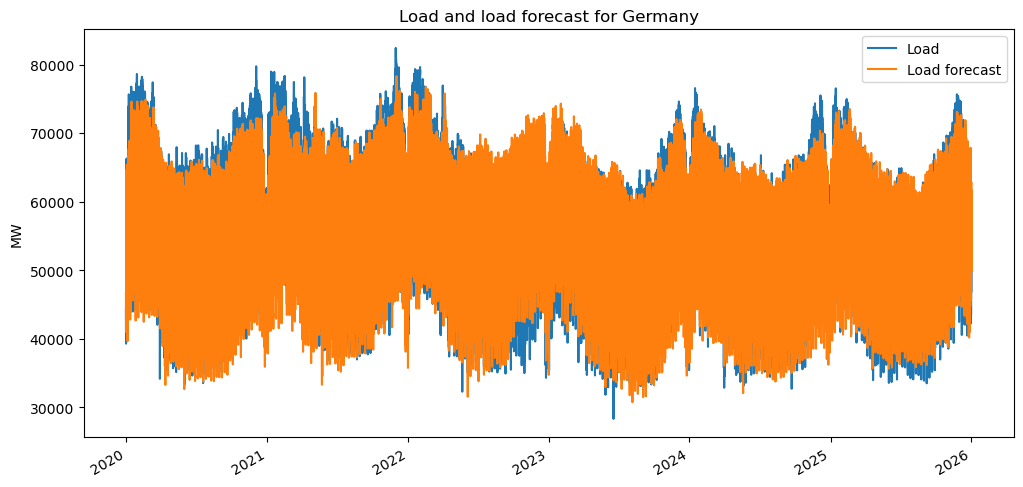

In [13]:
load_file_entsoe.plot(title='Load and load forecast for Germany',
                     figsize=(12,6),
                     ylabel='MW');

In [14]:
# =========================
#  have a quick look at the data
# =========================
print(load_file_entsoe.head())
print(load_file_entsoe.tail())

load_file_entsoe["Load"].describe()
load_file_entsoe["Load forecast"].describe()

                               Load  Load forecast
2020-01-01 00:00:00+01:00  44358.02       46652.97
2020-01-01 00:15:00+01:00  44110.13       46132.91
2020-01-01 00:30:00+01:00  43794.92       45651.74
2020-01-01 00:45:00+01:00  43610.84       45157.45
2020-01-01 01:00:00+01:00  43471.87       44316.96
                                  Load  Load forecast
2025-12-31 22:45:00+01:00  48381.93504   52598.106493
2025-12-31 23:00:00+01:00  47631.18725   51610.607829
2025-12-31 23:15:00+01:00  47309.17357   51120.316508
2025-12-31 23:30:00+01:00  47012.06983   50568.993942
2025-12-31 23:45:00+01:00  46883.97747   49862.908864


count    210227.000000
mean      54592.962559
std        9236.809024
min       30738.910000
25%       47053.790000
50%       54467.470000
75%       62184.855000
max       78313.130000
Name: Load forecast, dtype: float64

In [15]:

# Make working copy

df = load_file_entsoe.copy()
df = df.sort_index()

In [ ]:
# ======================
#  Force 15-minute grid
# ======================
df = df.asfreq("15min")

print("After asfreq('15min'):")
print(df.head())
print(df.tail())

After asfreq('15min'):
                               Load  Load forecast
2020-01-01 00:00:00+01:00  44358.02       46652.97
2020-01-01 00:15:00+01:00  44110.13       46132.91
2020-01-01 00:30:00+01:00  43794.92       45651.74
2020-01-01 00:45:00+01:00  43610.84       45157.45
2020-01-01 01:00:00+01:00  43471.87       44316.96
                                  Load  Load forecast
2025-12-31 22:45:00+01:00  48381.93504   52598.106493
2025-12-31 23:00:00+01:00  47631.18725   51610.607829
2025-12-31 23:15:00+01:00  47309.17357   51120.316508
2025-12-31 23:30:00+01:00  47012.06983   50568.993942
2025-12-31 23:45:00+01:00  46883.97747   49862.908864


In [17]:
# =========================
# Remove rows with missing values
# =========================
print("Missing values before dropna:")
print(df.isna().sum())

df = df.dropna()

print("\nMissing values after dropna:")
print(df.isna().sum())

Missing values before dropna:
Load               5
Load forecast    205
dtype: int64

Missing values after dropna:
Load             0
Load forecast    0
dtype: int64


In [18]:
# =========================
# Keep only complete 96-observation days
# =========================
daily_counts = df.groupby(df.index.date).size()

print("Daily observation counts before filtering:")
print(daily_counts.value_counts().sort_index())

valid_days = daily_counts[daily_counts == 96].index

df = df[pd.Series(df.index.date, index=df.index).isin(valid_days)]

print("\nDaily observation counts after filtering:")
print(df.groupby(df.index.date).size().value_counts().sort_index())

Daily observation counts before filtering:
92        6
95        5
96     2175
100       4
Name: count, dtype: int64

Daily observation counts after filtering:
96    2175
Name: count, dtype: int64


In [19]:

# =========================
# Construct error series
# =========================
df["error"] = df["Load"] - df["Load forecast"]

print(df[["Load", "Load forecast", "error"]].head())

                               Load  Load forecast    error
2020-01-01 00:00:00+01:00  44358.02       46652.97 -2294.95
2020-01-01 00:15:00+01:00  44110.13       46132.91 -2022.78
2020-01-01 00:30:00+01:00  43794.92       45651.74 -1856.82
2020-01-01 00:45:00+01:00  43610.84       45157.45 -1546.61
2020-01-01 01:00:00+01:00  43471.87       44316.96  -845.09


In [20]:
# =========================
#  Comprehensive sanity checks
# =========================
print("=" * 60)
print("1. Data shape")
print(df.shape)

print("\n2. Time range")
print(df.index.min())
print(df.index.max())

print("\n3. Missing values")
print(df.isna().sum())

print("\n4. Daily observations")
print(df.groupby(df.index.date).size().value_counts().sort_index())

print("\n5. Timezone")
print(df.index.tz)

print("\n6. Value range reasonableness")
print(df[["Load", "Load forecast"]].describe())

print("\n7. Error column confirmation")
print(df["error"].describe())

print("\n8. Duplicate timestamps")
print(f"Number of duplicate timestamps: {df.index.duplicated().sum()}")

1. Data shape
(208800, 3)

2. Time range
2020-01-01 00:00:00+01:00
2025-12-31 23:45:00+01:00

3. Missing values
Load             0
Load forecast    0
error            0
dtype: int64

4. Daily observations
96    2175
Name: count, dtype: int64

5. Timezone
Europe/Berlin

6. Value range reasonableness
                Load  Load forecast
count  208800.000000  208800.000000
mean    55007.633356   54644.871527
std      9700.510533    9236.510858
min     28308.000000   30738.910000
25%     47082.826750   47094.230000
50%     54982.970000   54572.450000
75%     62352.027500   62233.272500
max     82417.300000   78313.130000

7. Error column confirmation
count    208800.000000
mean        362.761829
std        2588.086163
min      -12323.470675
25%       -1262.117500
50%         390.862500
75%        2022.796728
max       11491.980000
Name: error, dtype: float64

8. Duplicate timestamps
Number of duplicate timestamps: 0


Daily MAE summary:
count    2175.000000
mean     2044.622156
std      1275.321757
min       280.237292
25%      1099.573125
50%      1692.017083
75%      2605.755688
max      8722.834896
Name: error, dtype: float64

Top 10 largest daily MAE:
2021-01-11    8722.834896
2021-01-05    8445.263750
2021-01-12    8261.399375
2021-04-07    7640.395938
2022-10-31    7603.899896
2022-10-03    7439.931771
2021-01-04    7405.920417
2025-12-30    6921.817328
2021-03-11    6893.180000
2024-05-10    6861.277708
Name: error, dtype: float64


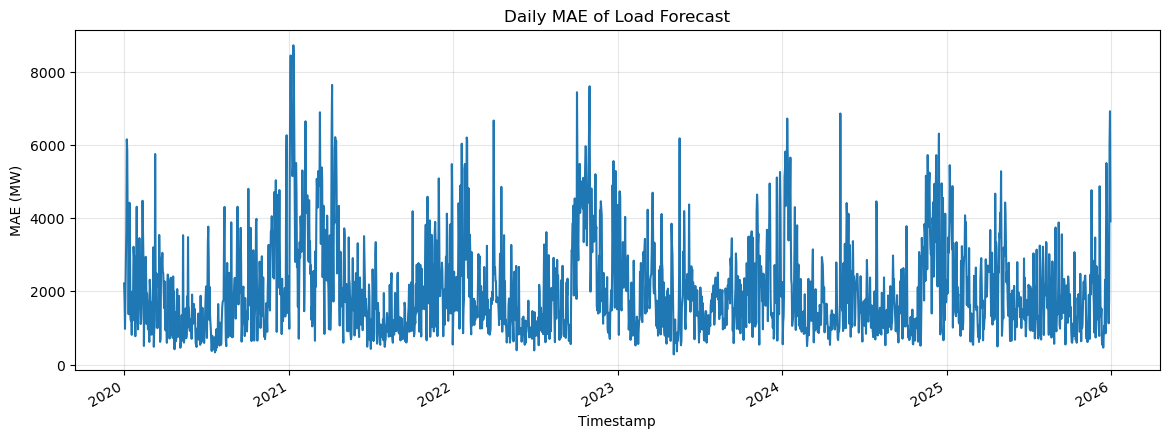

In [21]:
# =========================
# Daily MAE
# =========================
daily_mae = df.groupby(df.index.date)["error"].apply(lambda x: x.abs().mean())
daily_mae.index = pd.to_datetime(daily_mae.index)
daily_mae = daily_mae.dropna()


print("Daily MAE summary:")
print(daily_mae.describe())

print("\nTop 10 largest daily MAE:")
print(daily_mae.nlargest(10))

# =========================
#  Plot daily MAE
# =========================
plt.figure(figsize=(14, 5))
daily_mae.plot()
plt.title("Daily MAE of Load Forecast")
plt.ylabel("MAE (MW)")
plt.xlabel("Timestamp")
plt.grid(True, alpha=0.3)
plt.show()

Mean error (bias): 362.7618
Mean absolute error（MAE）: 2044.6222


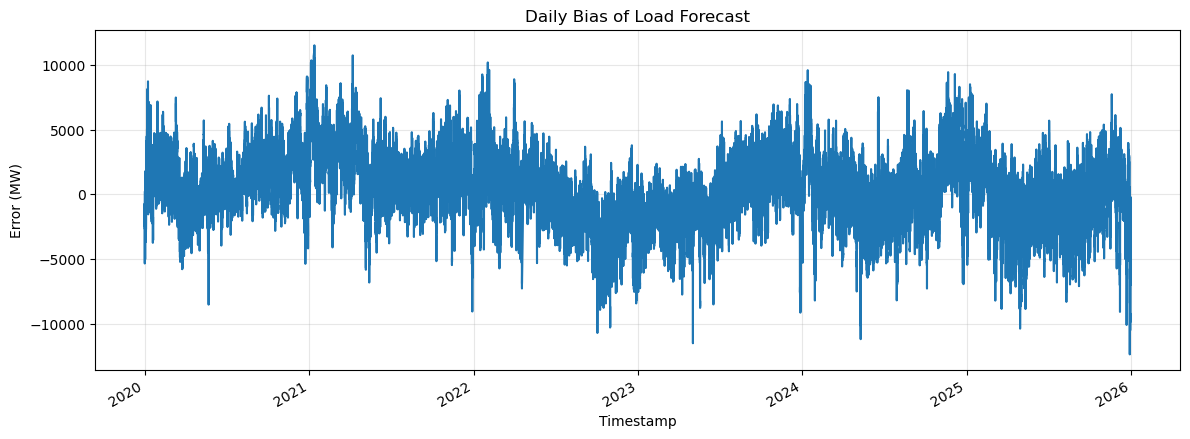

Error volatility diagnostics
Standard deviation of error: 2588.0862
Variance of error: 6698189.9882
MAPE: 3.74%
RMSE: 2613.3798 MW


In [22]:
# =========================
#  daily bias 
# =========================
daily_bias = df.groupby(df.index.date)["error"].mean()
daily_bias.index = pd.to_datetime(daily_bias.index)
daily_bias = daily_bias.dropna()


mean_error = df["error"].mean()
mean_abs_error = df["error"].abs().mean()


print(f"Mean error (bias): {mean_error:.4f}")
print(f"Mean absolute error（MAE）: {mean_abs_error:.4f}")

plt.figure(figsize=(14, 5))
df["error"].plot()
plt.title("Daily Bias of Load Forecast")
plt.ylabel("Error (MW)")
plt.xlabel("Timestamp")
plt.grid(True, alpha=0.3)
plt.show()

# =========================
#  Error volatility
# =========================
print("Error volatility diagnostics")
print(f"Standard deviation of error: {df['error'].std():.4f}")
print(f"Variance of error: {df['error'].var():.4f}")

# =========================
#  MAPE and RMSE
# =========================

mape = (df['error'].abs() / df['Load']).mean() * 100 
print(f"MAPE: {mape:.2f}%")

rmse = np.sqrt((df['error'] ** 2).mean())
print(f"RMSE: {rmse:.4f} MW")

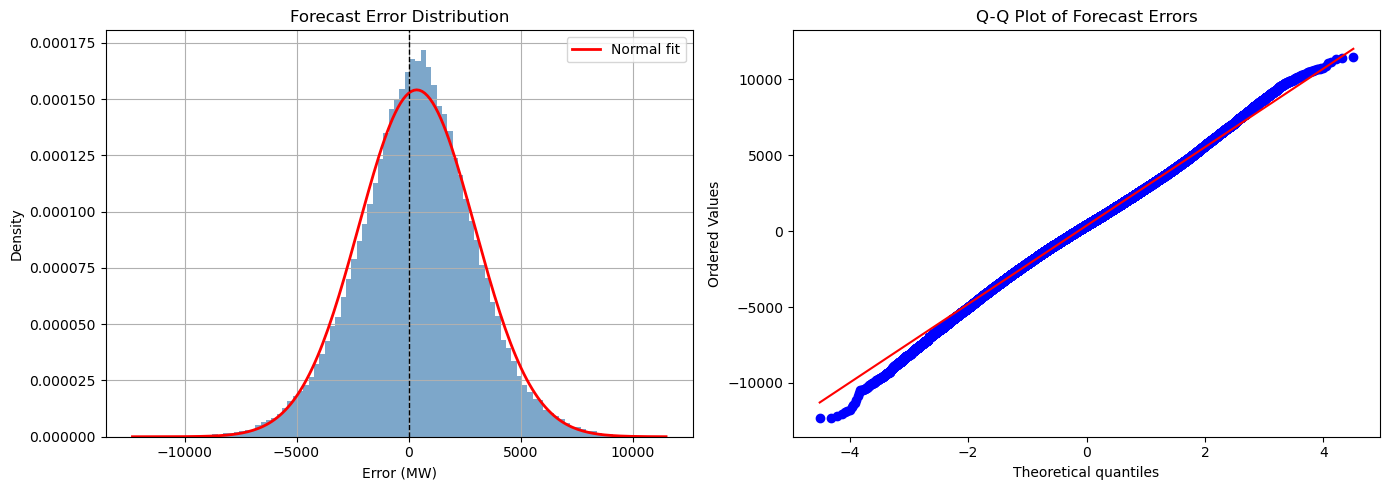

Skewness: -0.0497
Kurtosis: 0.4276


In [23]:
# =========================
#  error distribution analysis
# =========================
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram + normal fit
ax1 = axes[0]
df['error'].hist(bins=100, ax=ax1, density=True, alpha=0.7, color='steelblue')
mu, std = stats.norm.fit(df['error'])
x = np.linspace(df['error'].min(), df['error'].max(), 200)
ax1.plot(x, stats.norm.pdf(x, mu, std), 'r-', linewidth=2, label='Normal fit')
ax1.axvline(0, color='black', linestyle='--', linewidth=1)
ax1.set_title('Forecast Error Distribution')
ax1.set_xlabel('Error (MW)')
ax1.set_ylabel('Density')
ax1.legend()

# ：QQ plot
ax2 = axes[1]
stats.probplot(df['error'], dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot of Forecast Errors')

plt.tight_layout()
plt.show()

# statistics on raw error(15min intervals)
print(f"Skewness: {df['error'].skew():.4f}")
print(f"Kurtosis: {df['error'].kurtosis():.4f}")

<Figure size 1200x500 with 0 Axes>

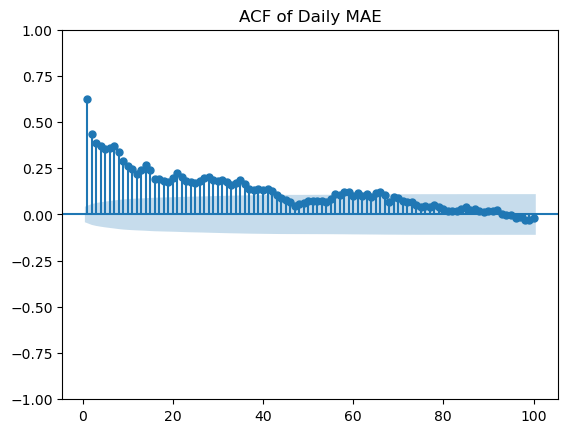

    lb_stat  lb_pvalue
7  2.76e+03   0.00e+00
14 3.87e+03   0.00e+00
20 4.38e+03   0.00e+00


In [24]:
# =========================
# Autocorrelation check
# =========================

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.figure(figsize=(12, 5))
plot_acf(daily_mae, lags=100,zero = False)
plt.title("ACF of Daily MAE")
plt.show()


pd.set_option('display.float_format', '{:.2e}'.format)
result = acorr_ljungbox(daily_mae, lags=[7, 14, 20], return_df=True)
print(result)

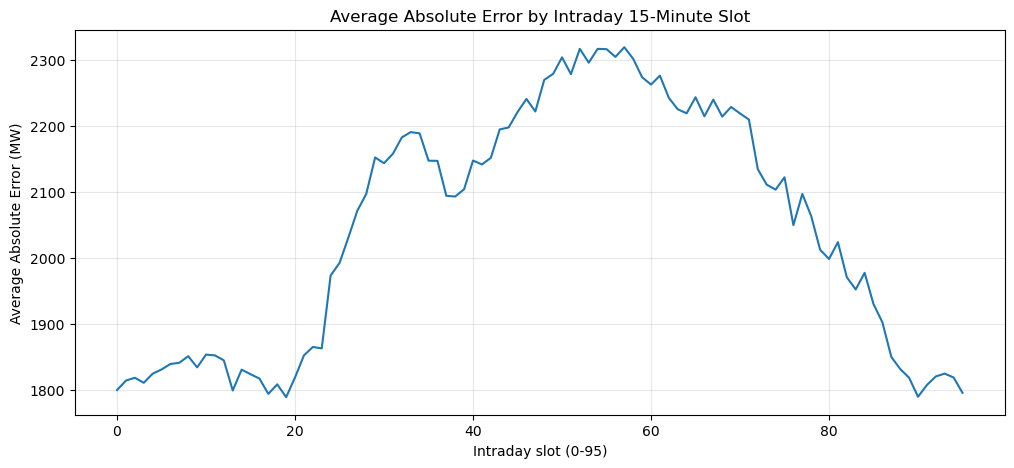

In [25]:
# =========================
#  Intraday error pattern
# =========================
intraday_slot = df.index.hour * 4 + df.index.minute // 15
intraday_mae = df.groupby(intraday_slot)["error"].apply(lambda x: x.abs().mean())

plt.figure(figsize=(12, 5))
intraday_mae.plot()
plt.title("Average Absolute Error by Intraday 15-Minute Slot")
plt.xlabel("Intraday slot (0-95)")
plt.ylabel("Average Absolute Error (MW)")
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
# =========================
# yearly statistics table
# =========================

yearly_stats = df.groupby(df.index.year).apply(
    lambda x: pd.Series({
        'MAE': x['error'].abs().mean(),
        'RMSE': np.sqrt((x['error']**2).mean()),
        'Bias': x['error'].mean(),
        'MAPE (%)': (x['error'].abs() / x['Load']).mean() * 100
    })
)

yearly_stats['RMSE/MAE'] = yearly_stats['RMSE'] / yearly_stats['MAE']
pd.set_option('display.float_format', '{:.3f}'.format)
print(yearly_stats.round(3))

print()

# =========================
# kruskal-wallis test for yearly MAE
# =========================

from scipy.stats import kruskal

mae_2023 = daily_mae[daily_mae.index.year == 2023]
mae_2024 = daily_mae[daily_mae.index.year == 2024]
mae_2025 = daily_mae[daily_mae.index.year == 2025]

stat, p = kruskal(mae_2023, mae_2024, mae_2025)

print(f"Kruskal-Wallis Test (2023 vs 2024 vs 2025)")
print(f"  H-statistic: {stat:.3f}")
print(f"  p-value:     {p:.3f}")
print(f"  Conclusion:  {'Significant difference between years (p < 0.05)' if p < 0.05 else 'No significant difference between years (p >= 0.05)'}")


          MAE     RMSE     Bias  MAPE (%)  RMSE/MAE
2020 1833.746 2325.832 1174.190     3.259     1.268
2021 2355.042 3003.116 1891.943     3.980     1.275
2022 2219.879 2824.450 -700.005     4.085     1.272
2023 1959.216 2412.783 -177.112     3.786     1.232
2024 1968.663 2554.373  419.802     3.685     1.298
2025 1933.976 2499.024 -441.427     3.674     1.292

Kruskal-Wallis Test (2023 vs 2024 vs 2025)
  H-statistic: 3.716
  p-value:     0.156
  Conclusion:  No significant difference between years (p >= 0.05)


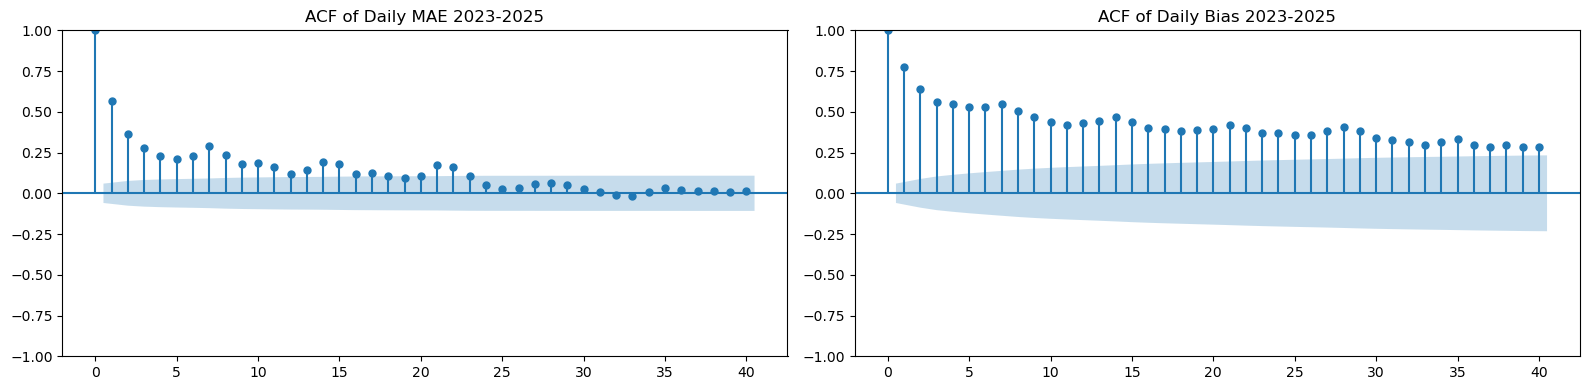

Ljung-Box test for stable period MAE
    lb_stat  lb_pvalue
7   829.566      0.000
14 1073.050      0.000
20 1176.811      0.000

Ljung-Box test for stable period Bias
    lb_stat  lb_pvalue
7  2724.070      0.000
14 4326.327      0.000
20 5390.906      0.000


In [27]:

# =========================
#  stable period 2023-2025 examination
# =========================
 
stable_peroid_mae  = daily_mae['2023':'2025'].dropna()
stable_peroid_bias = daily_bias['2023':'2025'].dropna()

# 5 ACF / serial dependence

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

plot_acf(stable_peroid_mae, lags=40, ax=axes[0])
axes[0].set_title("ACF of Daily MAE 2023-2025")

plot_acf(stable_peroid_bias, lags=40, ax=axes[1])
axes[1].set_title("ACF of Daily Bias 2023-2025")

plt.tight_layout()
plt.show()

# Ljung-Box
lb_mae = acorr_ljungbox(stable_peroid_mae, lags=[7, 14, 20], return_df=True)
lb_bias = acorr_ljungbox(stable_peroid_bias, lags=[7, 14, 20], return_df=True)

print("Ljung-Box test for stable period MAE")
print(lb_mae)
print("\nLjung-Box test for stable period Bias")
print(lb_bias)

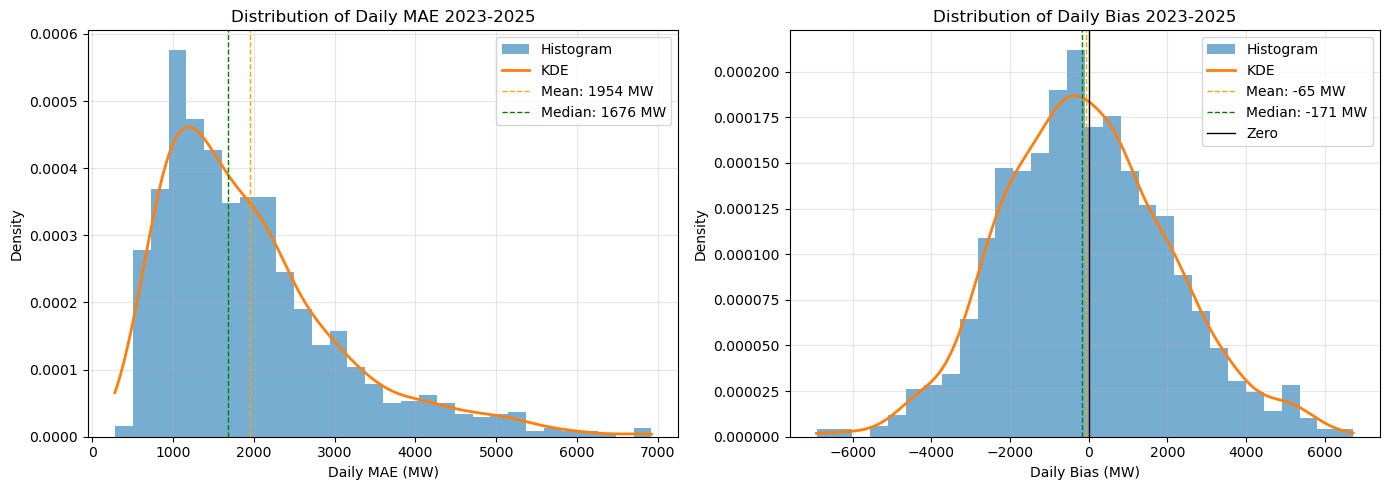

In [28]:
# =========================
# 2023-2025 error distribution of daily MAE and Bias
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- MAE Distribution ---
ax = axes[0]
ax.hist(stable_peroid_mae.dropna(), bins=30, density=True, alpha=0.6, label='Histogram')
kde = stats.gaussian_kde(stable_peroid_mae.dropna())
x = np.linspace(stable_peroid_mae.min(), stable_peroid_mae.max(), 300)
ax.plot(x, kde(x), linewidth=2, label='KDE')
ax.axvline(stable_peroid_mae.mean(), linestyle='--', color='orange', linewidth=1, label=f'Mean: {stable_peroid_mae.mean():.0f} MW')
ax.axvline(stable_peroid_mae.median(), linestyle='--', color='green', linewidth=1, label=f'Median: {stable_peroid_mae.median():.0f} MW')
ax.set_title("Distribution of Daily MAE 2023-2025")
ax.set_xlabel("Daily MAE (MW)")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Bias Distribution ---
ax = axes[1]
ax.hist(stable_peroid_bias.dropna(), bins=30, density=True, alpha=0.6, label='Histogram')
kde = stats.gaussian_kde(stable_peroid_bias.dropna())
x = np.linspace(stable_peroid_bias.min(), stable_peroid_bias.max(), 300)
ax.plot(x, kde(x), linewidth=2, label='KDE')
ax.axvline(stable_peroid_bias.mean(), linestyle='--', color='orange', linewidth=1, label=f'Mean: {stable_peroid_bias.mean():.0f} MW')
ax.axvline(stable_peroid_bias.median(), linestyle='--', color='green', linewidth=1, label=f'Median: {stable_peroid_bias.median():.0f} MW')
ax.axvline(0, linestyle='-', color='black', linewidth=1, label='Zero')
ax.set_title("Distribution of Daily Bias 2023-2025")
ax.set_xlabel("Daily Bias (MW)")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
# Skewness and kurtosis for stable period MAE and Bias
from scipy.stats import skew, kurtosis

print("Stable Period MAE skewness :", skew(stable_peroid_mae))
print("Stable Period MAE kurtosis :", kurtosis(stable_peroid_mae, fisher=True))

print("Stable Period Bias skewness:", skew(stable_peroid_bias))
print("Stable Period Bias kurtosis:", kurtosis(stable_peroid_bias, fisher=True))

Stable Period MAE skewness : 1.3593127715406847
Stable Period MAE kurtosis : 1.9769073376871606
Stable Period Bias skewness: 0.20652195133141896
Stable Period Bias kurtosis: 0.09898089016875744


In [30]:
# =========================
#  Yearly  and Quarterly summary table 2023-2025
# =========================
import pandas as pd

stable_peroid_df = pd.DataFrame({
    "MAE": stable_peroid_mae,
    "Bias": stable_peroid_bias
})

pd.set_option('display.float_format', '{:.3f}'.format)
# Annual statistics
stable_peroid_df["Year"] = stable_peroid_df.index.year
print("=== Annual Summary ===")
print(stable_peroid_df.groupby("Year")[["MAE", "Bias"]].agg(["mean", "median", "std"]).round(1))
print()

# Quarterly statistics (appendix)
stable_peroid_df["Quarter"] = stable_peroid_df.index.to_period("Q")
print("=== Quarterly Summary ===")
print(stable_peroid_df.groupby("Quarter")[["MAE", "Bias"]].agg(["mean", "std"]).round(1))

=== Annual Summary ===
          MAE                       Bias                  
         mean   median      std     mean   median      std
Year                                                      
2023 1959.200 1827.300 1007.800 -177.100 -183.200 2111.200
2024 1968.700 1499.700 1290.600  419.800  198.900 2195.900
2025 1934.000 1733.800 1043.400 -441.400 -495.400 2012.400

=== Quarterly Summary ===
             MAE               Bias         
            mean      std      mean      std
Quarter                                     
2023Q1  2158.800 1058.300 -2062.600 1188.900
2023Q2  1784.800 1024.900 -1498.000 1297.700
2023Q3  1613.600  623.300  1119.700 1021.800
2023Q4  2286.500 1115.400  1636.000 1861.200
2024Q1  2118.300 1525.100  1277.600 2149.300
2024Q2  1722.900  985.700  -963.100 1568.400
2024Q3  1527.800  696.000  -312.400 1422.500
2024Q4  2507.900 1541.700  1690.000 2346.600
2025Q1  2078.600 1083.400   938.800 1981.000
2025Q2  2062.700  976.600 -1566.600 1428.600
2025Q3  178

In [31]:
# =========================
#  seasonal summary table 2023-2025
# =========================

#  Assign season labels

def month_to_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

season_order = ["Winter", "Spring", "Summer", "Autumn"]

stable_peroid_df["Month"] = stable_peroid_df.index.month
stable_peroid_df["Season"] = stable_peroid_df["Month"].apply(month_to_season)
stable_peroid_df["Season"] = pd.Categorical(
    stable_peroid_df["Season"],
    categories=season_order,
    ordered=True
)

# -----------------------------
#  Seasonal summary table
# -----------------------------
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

seasonal_summary = stable_peroid_df.groupby("Season", observed=False)[["MAE", "Bias"]].agg(
    ["mean", "median", "std", iqr]
)

print("Seasonal summary table:")
print(seasonal_summary)


# -----------------------------
# 5. Kruskal–Wallis tests
# -----------------------------
mae_groups = [
    stable_peroid_df.loc[stable_peroid_df["Season"] == s, "MAE"].dropna()
    for s in season_order
]
bias_groups = [
    stable_peroid_df.loc[stable_peroid_df["Season"] == s, "Bias"].dropna()
    for s in season_order
]

kw_mae = kruskal(*mae_groups)
kw_bias = kruskal(*bias_groups)

print("\nKruskal–Wallis test for MAE across seasons:")
print(kw_mae)

print("\nKruskal–Wallis test for Bias across seasons:")
print(kw_bias)

Seasonal summary table:
            MAE                                 Bias                     \
           mean   median      std      iqr      mean    median      std   
Season                                                                    
Winter 2374.044 1987.570 1452.738 1971.485   622.858   771.858 2646.583   
Spring 1884.531 1622.876 1054.444 1437.414 -1233.336 -1257.492 1618.078   
Summer 1632.932 1509.814  687.000  937.425  -592.545  -630.424 1455.168   
Autumn 1935.581 1766.218 1039.219 1367.954   963.373   891.471 1861.204   

                 
            iqr  
Season           
Winter 3476.418  
Spring 2320.283  
Summer 2200.095  
Autumn 2563.241  

Kruskal–Wallis test for MAE across seasons:
KruskalResult(statistic=np.float64(29.979307852890997), pvalue=np.float64(1.3939575993583866e-06))

Kruskal–Wallis test for Bias across seasons:
KruskalResult(statistic=np.float64(197.10684031707206), pvalue=np.float64(1.7793901418448443e-42))


YEARLY SUMMARY (2023–2024)
          MAE                                Bias                           
         mean   median      std      iqr     mean   median      std      iqr
Year                                                                        
2023 1959.200 1827.300 1007.800 1206.700 -177.100 -183.200 2111.200 3374.600
2024 1968.700 1499.700 1290.600 1373.900  419.800  198.900 2195.900 2419.700

SEASONAL SUMMARY (2023–2024)
            MAE                                 Bias                    \
           mean   median      std      iqr      mean   median      std   
Season                                                                   
Winter 2408.800 2049.500 1486.900 2057.700   462.600  314.300 2737.100   
Spring 1786.200 1494.000 1067.000 1220.800 -1008.700 -820.900 1692.900   
Summer 1596.000 1483.400  661.700  922.300  -374.600 -512.300 1486.000   
Autumn 2076.100 1894.100 1113.000 1612.800  1418.800 1577.200 1770.600   

                 
            iqr  
Sea

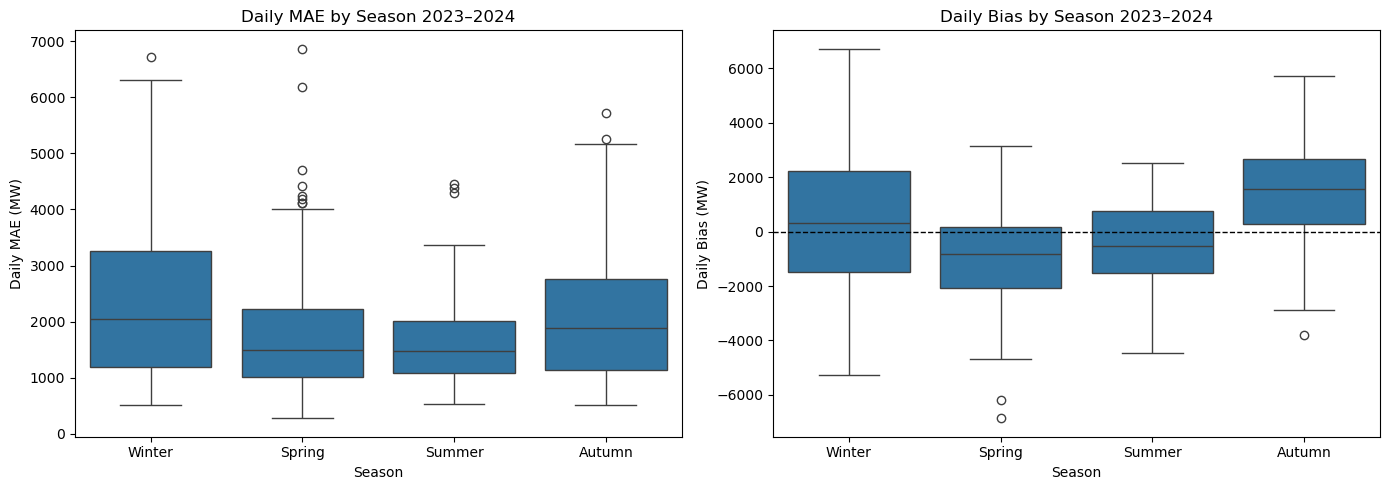

In [32]:
# =========================
# examnation of  2023-2024 
# =========================

# ─── 1.  Phase I baseline: 2023–2024 ───────────────────────
baseline_mae = daily_mae.loc['2023-01-01':'2024-12-31']
baseline_bias = daily_bias.loc['2023-01-01':'2024-12-31']

# ─── 2.  DataFrame ──────────────────────────────────────────
baseline_df = pd.DataFrame({
    "MAE": baseline_mae,
    "Bias": baseline_bias
}).copy()

baseline_df = baseline_df.dropna(subset=["MAE", "Bias"]).copy()


baseline_df["Year"] = baseline_df.index.year
baseline_df["Month"] = baseline_df.index.month
baseline_df["Season"] = baseline_df["Month"].apply(month_to_season)

season_order = ["Winter", "Spring", "Summer", "Autumn"]
baseline_df["Season"] = pd.Categorical(
    baseline_df["Season"],
    categories=season_order,
    ordered=True
)

# ─── 3. IQR function ────────────────────────────────────────────
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

# ─── 4. Yearly Summary ──────────────────────────────────────────
print("=" * 60)
print("YEARLY SUMMARY (2023–2024)")
print("=" * 60)

yearly = baseline_df.groupby("Year")[["MAE", "Bias"]].agg(
    ["mean", "median", "std", iqr]
).round(1)
print(yearly)

# ─── 5. Seasonal Summary ────────────────────────────────────────
print("\n" + "=" * 60)
print("SEASONAL SUMMARY (2023–2024)")
print("=" * 60)

seasonal = baseline_df.groupby("Season")[["MAE", "Bias"]].agg(
    ["mean", "median", "std", iqr]
).round(1)
print(seasonal)

# ─── 6. Bias Sign Table ─────────────────────────────────────────
print("\n" + "=" * 60)
print("BIAS SIGN BY SEASON")
print("=" * 60)

sign_table = baseline_df.groupby("Season")["Bias"].agg(
    mean="mean",
    median="median",
    pct_pos=lambda x: (x > 0).mean() * 100,
    pct_neg=lambda x: (x < 0).mean() * 100,
).round(1)

sign_table.columns = ["Mean (MW)", "Median (MW)", "% Days Positive", "% Days Negative"]
print(sign_table)

# ─── 7. Kruskal–Wallis Tests ────────────────────────────────────
print("\n" + "=" * 60)
print("KRUSKAL–WALLIS TEST (2023–2024)")
print("=" * 60)

mae_groups = [
    baseline_df.loc[baseline_df["Season"] == s, "MAE"].dropna()
    for s in season_order
]
bias_groups = [
    baseline_df.loc[baseline_df["Season"] == s, "Bias"].dropna()
    for s in season_order
]

kw_mae = kruskal(*mae_groups)
kw_bias = kruskal(*bias_groups)

print(f"MAE  — H = {kw_mae.statistic:.3f}, p = {kw_mae.pvalue:.2e}")
print(f"Bias — H = {kw_bias.statistic:.3f}, p = {kw_bias.pvalue:.2e}")

# -----------------------------
# Boxplots by season
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=baseline_df, x="Season", y="MAE", order=season_order, ax=axes[0])
axes[0].set_title("Daily MAE by Season 2023–2024")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Daily MAE (MW)")

sns.boxplot(data=baseline_df, x="Season", y="Bias", order=season_order, ax=axes[1])
axes[1].set_title("Daily Bias by Season 2023–2024")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Daily Bias (MW)")
axes[1].axhline(0, linestyle="--", linewidth=1, color="black")
plt.savefig("boxplot_season.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()




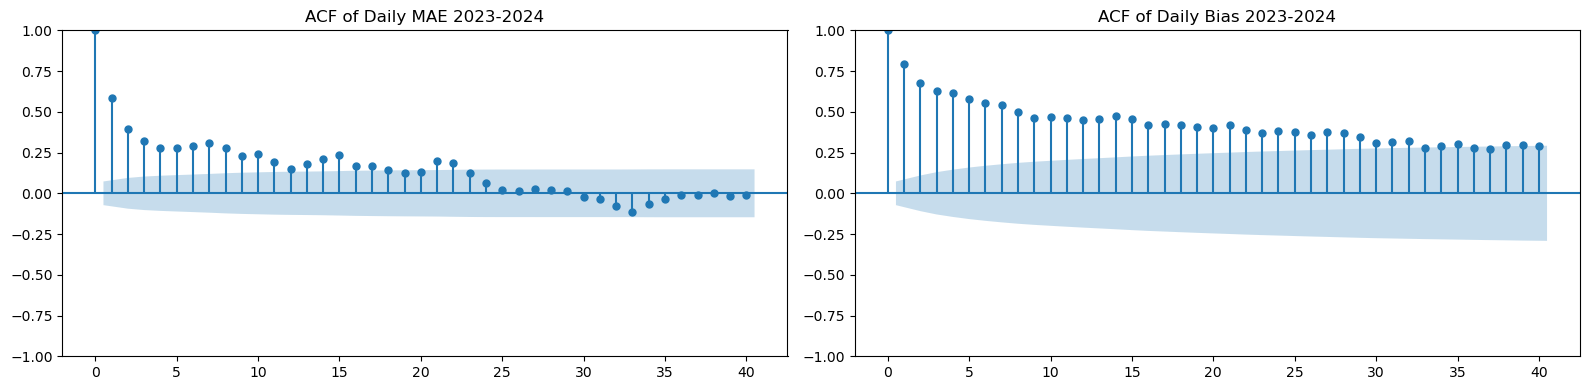

Ljung-Box test for baseline MAE
    lb_stat  lb_pvalue
7   685.114      0.000
14  925.174      0.000
20 1048.005      0.000

Ljung-Box test for baseline Bias
    lb_stat  lb_pvalue
7  2052.128      0.000
14 3184.501      0.000
20 3981.983      0.000


In [33]:
#  ACF / serial dependence baseline 2023–2024

baseline_mae = daily_mae.loc['2023-01-01':'2024-12-31'].dropna()
baseline_bias = daily_bias.loc['2023-01-01':'2024-12-31'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

plot_acf(baseline_mae, lags=40, ax=axes[0])
axes[0].set_title("ACF of Daily MAE 2023-2024")

plot_acf(baseline_bias, lags=40, ax=axes[1])
axes[1].set_title("ACF of Daily Bias 2023-2024")

plt.tight_layout()
plt.show()

# Ljung-Box
lb_mae = acorr_ljungbox(baseline_mae, lags=[7, 14, 20], return_df=True)
lb_bias = acorr_ljungbox(baseline_bias, lags=[7, 14, 20], return_df=True)

print("Ljung-Box test for baseline MAE")
print(lb_mae)
print("\nLjung-Box test for baseline Bias")
print(lb_bias)

In [34]:
# =========================
# seasonal Bias Centering
# =========================
# Seasonal means and medians for Bias in Phase I
bias_season_mean = baseline_df.groupby("Season")["Bias"].mean()
bias_season_median = baseline_df.groupby("Season")["Bias"].median()

# Mean-centered Bias
baseline_df["Bias_centered_mean"] = baseline_df.apply(
    lambda row: row["Bias"] - bias_season_mean.loc[row["Season"]],
    axis=1
)

# Median-centered Bias
baseline_df["Bias_centered_median"] = baseline_df.apply(
    lambda row: row["Bias"] - bias_season_median.loc[row["Season"]],
    axis=1
)

# Check seasonal summaries after centering
centered_mean_summary = baseline_df.groupby("Season")["Bias_centered_mean"].agg(
    ["mean", "median", "std"]
).round(1)

centered_median_summary = baseline_df.groupby("Season")["Bias_centered_median"].agg(
    ["mean", "median", "std"]
).round(1)

print("Mean-centered Bias summary by season:")
print(centered_mean_summary)

print("\nMedian-centered Bias summary by season:")
print(centered_median_summary)

Mean-centered Bias summary by season:
         mean   median      std
Season                         
Winter  0.000 -148.200 2737.100
Spring -0.000  187.800 1692.900
Summer  0.000 -137.700 1486.000
Autumn -0.000  158.400 1770.600

Median-centered Bias summary by season:
           mean  median      std
Season                          
Winter  148.200   0.000 2737.100
Spring -187.800   0.000 1692.900
Summer  137.700  -0.000 1486.000
Autumn -158.400   0.000 1770.600


In [35]:
from scipy.stats import kruskal, levene

season_order = ["Winter", "Spring", "Summer", "Autumn"]

# KW test after mean-centering
groups_mean = [
    baseline_df.loc[baseline_df["Season"] == s, "Bias_centered_mean"].dropna()
    for s in season_order
]
kw_after_mean = kruskal(*groups_mean)

# KW test after median-centering
groups_median = [
    baseline_df.loc[baseline_df["Season"] == s, "Bias_centered_median"].dropna()
    for s in season_order
]
kw_after_median = kruskal(*groups_median)

print("Kruskal-Wallis BEFORE centering: H = 134.783, p = 5.04e-29")
print(f"Kruskal-Wallis AFTER mean-centering:   H = {kw_after_mean.statistic:.3f}, p = {kw_after_mean.pvalue:.4f}")
print(f"Kruskal-Wallis AFTER median-centering: H = {kw_after_median.statistic:.3f}, p = {kw_after_median.pvalue:.4f}")

# Levene test：
levene_after = levene(*groups_mean)
print(f"\nLevene test after mean-centering: F = {levene_after.statistic:.3f}, p = {levene_after.pvalue:.4f}")

Kruskal-Wallis BEFORE centering: H = 134.783, p = 5.04e-29
Kruskal-Wallis AFTER mean-centering:   H = 0.787, p = 0.8526
Kruskal-Wallis AFTER median-centering: H = 3.001, p = 0.3915

Levene test after mean-centering: F = 28.535, p = 0.0000


In [36]:
# Season-specific std for scaling
bias_season_std = baseline_df.groupby("Season")["Bias"].std()

season_str = baseline_df["Season"].astype(str)

# Standardized Bias
baseline_df["Bias_standardized"] = (
    baseline_df["Bias"] - season_str.map(bias_season_mean)
) / season_str.map(bias_season_std)

# Verify
std_summary = baseline_df.groupby("Season")["Bias_standardized"].agg(
    ["mean", "std", "median"]
).round(3)
print("Standardized Bias summary by season:")
print(std_summary)

# KW and levene after standardization
groups_std = [
    baseline_df.loc[baseline_df["Season"] == s, "Bias_standardized"].dropna()
    for s in season_order
]
kw_std = kruskal(*groups_std)
levene_std = levene(*groups_std)

print(f"\nKruskal-Wallis after standardization: H = {kw_std.statistic:.3f}, p = {kw_std.pvalue:.4f}")
print(f"Levene after standardization: F = {levene_std.statistic:.3f}, p = {levene_std.pvalue:.4f}")

print()

# Brown–Forsythe test for MAE dispersion across seasons (MAE is right skewed, so median-based test is more robust)
mae_groups = [
    baseline_df.loc[baseline_df["Season"] == s, "MAE"].dropna()
    for s in season_order
]

bf_mae = levene(*mae_groups, center="median")

print(f"Brown–Forsythe test for MAE dispersion: F = {bf_mae.statistic:.3f}, p = {bf_mae.pvalue:.4f}")

Standardized Bias summary by season:
         mean   std  median
Season                     
Winter  0.000 1.000  -0.054
Spring -0.000 1.000   0.111
Summer  0.000 1.000  -0.093
Autumn -0.000 1.000   0.089

Kruskal-Wallis after standardization: H = 0.290, p = 0.9619
Levene after standardization: F = 0.058, p = 0.9817

Brown–Forsythe test for MAE dispersion: F = 24.443, p = 0.0000


In [37]:
# correlation between daily MAE and Bias Pearson and Spearman （Appendix)
# 2020-2025 full period
daily_mae2 = daily_mae.copy()
daily_bias2 = daily_bias.copy()

daily_mae2.index = pd.to_datetime(daily_mae2.index)
daily_bias2.index = pd.to_datetime(daily_bias2.index)

daily_mae2.index = daily_mae2.index.normalize()
daily_bias2.index = daily_bias2.index.normalize()

tmp = pd.concat([daily_mae2, daily_bias2], axis=1)
tmp.columns = ["MAE", "Bias"]
tmp["AbsBias"] = tmp["Bias"].abs()

print(tmp[["MAE", "Bias", "AbsBias"]].corr(method="pearson"))
print(tmp[["MAE", "Bias", "AbsBias"]].corr(method="spearman"))


          MAE  Bias  AbsBias
MAE     1.000 0.206    0.976
Bias    0.206 1.000    0.205
AbsBias 0.976 0.205    1.000
          MAE  Bias  AbsBias
MAE     1.000 0.188    0.940
Bias    0.188 1.000    0.201
AbsBias 0.940 0.201    1.000


                MAE      Bias  AbsBias
2023-01-02 4366.310 -4366.310 4366.310
2023-01-03 4057.981 -4057.981 4057.981
2023-01-04  812.331  -742.917  742.917
2023-01-05 4684.969 -4684.969 4684.969
2023-01-06 4734.764 -4734.764 4734.764
(727, 3)
Pearson correlations (Phase I 2023-2024):
          MAE  Bias  AbsBias
MAE     1.000 0.190    0.972
Bias    0.190 1.000    0.175
AbsBias 0.972 0.175    1.000

Spearman correlations (Phase I 2023-2024):
          MAE  Bias  AbsBias
MAE     1.000 0.077    0.928
Bias    0.077 1.000    0.069
AbsBias 0.928 0.069    1.000


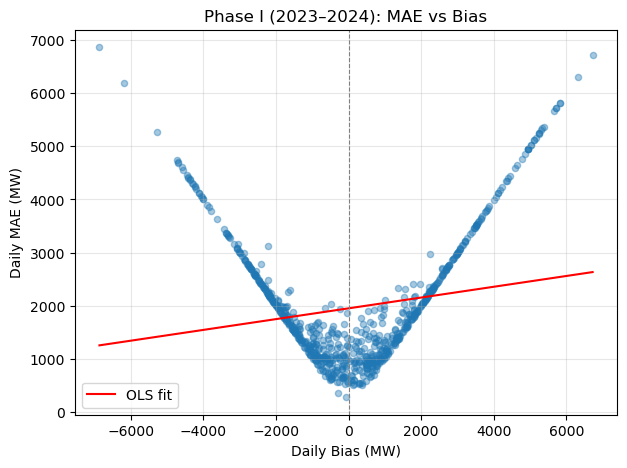


                               Load  Load forecast     error
2023-01-02 00:00:00+01:00 37869.940      44952.100 -7082.160
2023-01-02 00:15:00+01:00 37557.300      44665.410 -7108.110
2023-01-02 00:30:00+01:00 36853.230      44222.490 -7369.260
2023-01-02 00:45:00+01:00 36356.930      43875.470 -7518.540
2023-01-02 01:00:00+01:00 36022.140      43309.750 -7287.610
...                             ...            ...       ...
2023-01-06 22:45:00+01:00 49588.400      54385.330 -4796.930
2023-01-06 23:00:00+01:00 48512.430      53598.300 -5085.870
2023-01-06 23:15:00+01:00 47595.490      53155.140 -5559.650
2023-01-06 23:30:00+01:00 46634.280      52488.120 -5853.840
2023-01-06 23:45:00+01:00 45710.830      51773.190 -6062.360

[480 rows x 3 columns]


In [38]:
# Appendix: Correlation between daily MAE and Bias in Phase I (2023–2024)

phase1 = tmp.loc["2023-01-01":"2024-12-31"].dropna()

print(phase1.head())
print(phase1.shape)

# Pearson correlation
print("Pearson correlations (Phase I 2023-2024):")
print(phase1[["MAE", "Bias", "AbsBias"]].corr(method="pearson"))

print()

# Spearman correlation
print("Spearman correlations (Phase I 2023-2024):")
print(phase1[["MAE", "Bias", "AbsBias"]].corr(method="spearman"))


plt.figure(figsize=(7, 5))
plt.scatter(phase1["Bias"], phase1["MAE"], alpha=0.4, s=20)


z = np.polyfit(phase1["Bias"].dropna(), phase1["MAE"].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(phase1["Bias"].min(), phase1["Bias"].max(), 300)
plt.plot(x_line, p(x_line), color="red", linewidth=1.5, label="OLS fit")

plt.axvline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Daily Bias (MW)")
plt.ylabel("Daily MAE (MW)")
plt.title("Phase I (2023–2024): MAE vs Bias")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print()
# 2023-01-02 to 2023-01-06 error pattern
print(df.loc["2023-01-02":"2023-01-06", ["Load", "Load forecast", "error"]])

#"During public holiday periods such as the New Year period (2023-01-02 to 2023-01-06), 
# the model exhibits systematic over-forecasting with errors consistently ranging 
# from -4,000 to -7,500 MW, as the model does not explicitly account for holiday 
# load patterns. This results in daily MAE equaling |daily Bias|, 
# since all intraday errors share the same sign."

In [39]:
# =========================
# EWMA + MBB Bootstrap
# =========================

# ── Phase I ──
phase1_mae  = baseline_df["MAE"].dropna().copy()
phase1_zbias = baseline_df["Bias_standardized"].dropna().copy()

# 
assert phase1_mae.index.equals(phase1_zbias.index), "MAE and ZBias indices do not match!"

phase1_season = baseline_df.loc[phase1_mae.index, "Season"].astype(str).copy()

print(f"Phase I sample: {len(phase1_mae)} days")
print(phase1_season.value_counts())

print()
# =========================
# EWMA function
# =========================
LAM = 0.2  

def compute_ewma(series_array, lam, init):
    """
    E_t = lam * X_t + (1-lam) * E_{t-1}
    series_array : np.ndarray
    init         :  E_0
    """
    series_array = np.asarray(series_array, dtype=float)
    T = len(series_array)
    ewma = np.empty(T,dtype=float)
    ewma[0] = lam * series_array[0] + (1 - lam) * init
    for t in range(1, T):
        ewma[t] = lam * series_array[t] + (1 - lam) * ewma[t - 1]
    return ewma

# Initial values consistent with thesis design 
init_mae  = phase1_mae.mean()   # MAE chart: Phase I mean
init_zbias = 0.0                 # Bias chart: centered at zero after standardization

#  orignial Phase I EWMA paths
ewma_mae_phase1   = compute_ewma(phase1_mae.values,   LAM, init_mae)
ewma_zbias_phase1 = compute_ewma(phase1_zbias.values, LAM, init_zbias)

print(f"EWMA MAE   — mean: {ewma_mae_phase1.mean():.1f}, max: {ewma_mae_phase1.max():.1f}")
print(f"EWMA ZBias — mean: {ewma_zbias_phase1.mean():.3f}, max: {ewma_zbias_phase1.max():.3f}")

Phase I sample: 727 days
Season
Summer    184
Spring    182
Autumn    182
Winter    179
Name: count, dtype: int64

EWMA MAE   — mean: 1961.9, max: 5073.4
EWMA ZBias — mean: -0.001, max: 1.688


In [40]:

# =========================================================
#  global Moving Block Bootstrap helper
# =========================================================
def mbb_resample_path(series, block_length, rng):
    """
    Create one moving block bootstrap sample of the same length as series.
    """
    series = np.asarray(series, dtype=float)
    T = len(series)

    if block_length > T:
        raise ValueError("block_length cannot exceed sample length.")

    start_indices = np.arange(T - block_length + 1)
    n_blocks_needed = int(np.ceil(T / block_length))

    starts = rng.choice(start_indices, size=n_blocks_needed, replace=True)
    boot = np.concatenate([series[s:s + block_length] for s in starts])[:T]
    return boot

# =========================================================
#  Global MBB + season-conditioned UCL for MAE chart
# =========================================================
def mbb_global_seasonal_ucl(
    series, seasons, lam, init,
    block_length=21, B=5000, quantile=0.995, seed=42
):
    """
    Global moving block bootstrap for MAE chart,
    with season-conditioned upper control limits.

    Parameters
    ----------
    series : np.ndarray
        Phase I raw MAE series in time order.
    seasons : np.ndarray of str
        Season label for each time position in Phase I.
    lam : float
        EWMA smoothing parameter.
    init : float
        Initial EWMA value E_0.
    block_length : int
        MBB block length.
    B : int
        Number of bootstrap replications.
    quantile : float
        Upper quantile level for UCL.
    seed : int
        Random seed.

    Returns
    -------
    seasonal_ucl : dict
        Season-specific UCL, e.g. {"Winter": ..., ...}
    all_paths : np.ndarray
        Bootstrap EWMA paths, shape (B, T)
    """
    rng = np.random.default_rng(seed)
    series = np.asarray(series, dtype=float)
    seasons = np.asarray(seasons)
    T = len(series)

    if len(seasons) != T:
        raise ValueError("series and seasons must have the same length.")

    all_paths = np.empty((B, T), dtype=float)

    for b in range(B):
        boot = mbb_resample_path(series, block_length=block_length, rng=rng)
        all_paths[b] = compute_ewma(boot, lam=lam, init=init)

    seasonal_ucl = {}
    for s in np.unique(seasons):
        mask = (seasons == s)
        season_values = all_paths[:, mask].ravel()
        seasonal_ucl[s] = np.quantile(season_values, quantile)

    return seasonal_ucl, all_paths

# =========================================================
# 4. Main specification for MAE chart
# =========================================================
BLOCK_LENGTH = 21   # main specification
B_REP = 5000
UPPER_Q = 0.995
SEED = 42

ucl_mae_B, paths_mae_B = mbb_global_seasonal_ucl(
    series=phase1_mae.values,
    seasons=phase1_season.values,
    lam=LAM,
    init=init_mae,
    block_length=BLOCK_LENGTH,
    B=B_REP,
    quantile=UPPER_Q,
    seed=SEED
)

# =========================================================
# Print season-specific UCLs
# =========================================================
season_order = ["Winter", "Spring", "Summer", "Autumn"]

print("\nMAE chart: season-conditioned UCLs")
print(f"{'Season':<10} {'UCL_MAE (MW)':>14}")
print("-" * 26)
for s in season_order:
    if s in ucl_mae_B:
        print(f"{s:<10} {ucl_mae_B[s]:>14.1f}")

# =========================================================
#  Phase I exceedance check
# =========================================================
ucl_aligned = phase1_season.map(ucl_mae_B)

if ucl_aligned.isna().any():
    missing_seasons = phase1_season[ucl_aligned.isna()].unique()
    raise ValueError(f"Missing UCL for seasons: {missing_seasons}")

mae_alarm_phase1 = ewma_mae_phase1 > ucl_aligned.to_numpy()

print("\nPhase I MAE alarm summary")
print(f"MAE alarms in Phase I: {mae_alarm_phase1.sum()} / {len(mae_alarm_phase1)}")


MAE chart: season-conditioned UCLs
Season       UCL_MAE (MW)
--------------------------
Winter             4733.4
Spring             4717.7
Summer             4713.1
Autumn             4733.8

Phase I MAE alarm summary
MAE alarms in Phase I: 6 / 727


In [41]:
# NOTE: exploratory only — uses Scheme B (global MBB) UCL from Cell 31.
# Main specification uses alarm_df_A (Scheme A, Cell 34).
# Do NOT rely on alarm_df for downstream analysis.
# Phase I alarm table by season （global MBB + season-conditioned UCL specification）
alarm_df = pd.DataFrame({
    "EWMA_MAE": ewma_mae_phase1,
    "UCL": ucl_aligned,
    "Season": phase1_season.values,
    "Alarm": mae_alarm_phase1
}, index=phase1_mae.index)

print("Phase I MAE alarm by season:")
print(alarm_df.groupby("Season")["Alarm"].agg(
    total="count",
    alarms="sum",
    alarm_rate=lambda x: f"{x.mean()*100:.2f}%"
).loc[season_order])

Phase I MAE alarm by season:
        total  alarms alarm_rate
Season                          
Winter    179       6      3.35%
Spring    182       0      0.00%
Summer    184       0      0.00%
Autumn    182       0      0.00%


In [42]:
print("Current init_mae:", init_mae)
print("Phase I MAE mean:", phase1_mae.mean())

Current init_mae: 1963.9458493767195
Phase I MAE mean: 1963.9458493767195


In [43]:
# =========================================================
#  Phase I input for MAE chart
# =========================================================

phase1_mae = baseline_df["MAE"].dropna().copy()
phase1_season = baseline_df.loc[phase1_mae.index, "Season"].astype(str).copy()

season_order = ["Winter", "Spring", "Summer", "Autumn"]

print(f"Phase I MAE sample: {len(phase1_mae)} days")
print(phase1_season.value_counts().reindex(season_order))

# =========================================================
# 1. EWMA function
# =========================================================
LAM = 0.2

def compute_ewma(series_array, lam, init):
    """
    EWMA recursion:
        E_t = lam * X_t + (1-lam) * E_{t-1}
    where init is E_0.

    Parameters
    ----------
    series_array : np.ndarray
        Input series in time order.
    lam : float
        EWMA smoothing parameter.
    init : float
        Initial value E_0.

    Returns
    -------
    ewma : np.ndarray
        EWMA path of same length as input.
        ewma[0] corresponds to E_1 in the recursion.
    """
    series_array = np.asarray(series_array, dtype=float)
    T = len(series_array)
    ewma = np.empty(T, dtype=float)

    ewma[0] = lam * series_array[0] + (1 - lam) * init
    for t in range(1, T):
        ewma[t] = lam * series_array[t] + (1 - lam) * ewma[t - 1]
    return ewma

# =========================================================
# 2. Full-calendar EWMA path (the monitored object)
# =========================================================
# keep the same init for both full-calendar path and bootstrap paths to ensure comparability
init_mae = phase1_mae.mean()
ewma_mae_phase1 = compute_ewma(phase1_mae.values, lam=LAM, init=init_mae)

print(f"\nFull-calendar EWMA MAE — mean: {ewma_mae_phase1.mean():.1f}, "
      f"min: {ewma_mae_phase1.min():.1f}, max: {ewma_mae_phase1.max():.1f}")

# =========================================================
# 3.  Moving Block Bootstrap helper
# =========================================================
def mbb_resample_path(series, block_length, rng):
    """
    Create one moving block bootstrap sample of the same length as series.
    """
    series = np.asarray(series, dtype=float)
    T = len(series)

    if block_length > T:
        raise ValueError("block_length cannot exceed sample length.")

    start_indices = np.arange(T - block_length + 1)
    n_blocks_needed = int(np.ceil(T / block_length))

    starts = rng.choice(start_indices, size=n_blocks_needed, replace=True)
    boot = np.concatenate([series[s:s + block_length] for s in starts])[:T]
    return boot

# =========================================================
# 4. Scheme A:
#    season-specific independent bootstrap calibration
# =========================================================
def mbb_by_season_ucl(
    series, seasons, lam, init,
    block_length=21, B=5000, quantile=0.995, seed=42
):
    """
    Scheme A:
    Calibrate MAE UCL separately within each seasonal subseries.

    IMPORTANT:
    This function operates on season-specific subseries, not on the
    full calendar-time series. Therefore, it is best interpreted as an
    alternative / robustness design emphasizing seasonal adaptation.

    Parameters
    ----------
    series : np.ndarray
        Full Phase I raw MAE series in original time order.
    seasons : np.ndarray of str
        Season label for each time point.
    lam : float
        EWMA smoothing parameter.
    init : float
        Global initial EWMA value E_0 used in bootstrap EWMA construction.
    block_length : int
        MBB block length.
    B : int
        Number of bootstrap replications.
    quantile : float
        Upper quantile level for UCL.
    seed : int
        Random seed.

    Returns
    -------
    ucl : dict
        Season-specific UCL.
    season_paths : dict
        Bootstrap EWMA paths for each season.
    season_sizes : dict
        Sample size for each season.
    """
    rng = np.random.default_rng(seed)
    series = np.asarray(series, dtype=float)
    seasons = np.asarray(seasons)

    if len(series) != len(seasons):
        raise ValueError("series and seasons must have the same length.")

    ucl = {}
    season_paths = {}
    season_sizes = {}

    for s in np.unique(seasons):
        mask = (seasons == s)
        s_series = series[mask]
        T_s = len(s_series)
        season_sizes[s] = T_s

        if block_length > T_s:
            raise ValueError(
                f"block_length={block_length} exceeds sample length in {s} (T={T_s})"
            )

        all_paths = np.empty((B, T_s), dtype=float)

        for b in range(B):
            boot = mbb_resample_path(s_series, block_length=block_length, rng=rng)
            all_paths[b] = compute_ewma(boot, lam=lam, init=init)

        ucl[s] = np.quantile(all_paths.ravel(), quantile)
        season_paths[s] = all_paths

    return ucl, season_paths, season_sizes

# =========================================================
# 5. Main specification for Scheme A
# =========================================================
BLOCK_LENGTH = 21
B_REP = 5000
UPPER_Q = 0.995
SEED = 42

ucl_mae_A, paths_mae_A, season_sizes_A = mbb_by_season_ucl(
    series=phase1_mae.values,
    seasons=phase1_season.values,
    lam=LAM,
    init=init_mae,          
    block_length=BLOCK_LENGTH,
    B=B_REP,
    quantile=UPPER_Q,
    seed=SEED
)

# =========================================================
# 6. Print season-specific UCLs
# =========================================================
print("\nScheme A: season-specific independent UCLs")
print(f"{'Season':<10} {'SampleSize':>10} {'UCL_MAE (MW)':>14}")
print("-" * 38)
for s in season_order:
    if s in ucl_mae_A:
        print(f"{s:<10} {season_sizes_A[s]:>10} {ucl_mae_A[s]:>14.1f}")

# =========================================================
# 7. Align UCLs back to full-calendar dates
# =========================================================
ucl_aligned_A = phase1_season.map(ucl_mae_A)

if ucl_aligned_A.isna().any():
    missing_seasons = phase1_season[ucl_aligned_A.isna()].unique()
    raise ValueError(f"Missing UCL for seasons: {missing_seasons}")

mae_alarm_A = ewma_mae_phase1 > ucl_aligned_A.to_numpy()

# =========================================================
# 8. Phase I alarm summary by season
# =========================================================
alarm_df_A = pd.DataFrame({
    "EWMA_MAE": ewma_mae_phase1,
    "UCL": ucl_aligned_A.to_numpy(),
    "Season": phase1_season.values,
    "Alarm": mae_alarm_A
}, index=phase1_mae.index)

alarm_summary_A = alarm_df_A.groupby("Season")["Alarm"].agg(
    total="count",
    alarms="sum",
    alarm_rate=lambda x: x.mean()
).reindex(season_order)

alarm_summary_A["alarm_rate_pct"] = (alarm_summary_A["alarm_rate"] * 100).round(2)

print("\nPhase I MAE alarm by season (Scheme A)")
print(alarm_summary_A)

# =========================================================
# 9. Optional comparison with Scheme B
# =========================================================


if "ucl_mae_B" in globals():
    print("\nScheme A vs Scheme B UCL comparison")
    print(f"{'Season':<10} {'UCL_A':>12} {'UCL_B':>12} {'Diff(A-B)':>12}")
    print("-" * 46)
    for s in season_order:
        if s in ucl_mae_A and s in ucl_mae_B:
            diff = ucl_mae_A[s] - ucl_mae_B[s]
            print(f"{s:<10} {ucl_mae_A[s]:>12.1f} {ucl_mae_B[s]:>12.1f} {diff:>12.1f}")

Phase I MAE sample: 727 days
Season
Winter    179
Spring    182
Summer    184
Autumn    182
Name: count, dtype: int64

Full-calendar EWMA MAE — mean: 1961.9, min: 847.2, max: 5073.4

Scheme A: season-specific independent UCLs
Season     SampleSize   UCL_MAE (MW)
--------------------------------------
Winter            179         5038.5
Spring            182         3136.5
Summer            184         2406.3
Autumn            182         4215.7

Phase I MAE alarm by season (Scheme A)
        total  alarms  alarm_rate  alarm_rate_pct
Season                                           
Winter    179       1       0.006           0.560
Spring    182       1       0.005           0.550
Summer    184       3       0.016           1.630
Autumn    182       2       0.011           1.100

Scheme A vs Scheme B UCL comparison
Season            UCL_A        UCL_B    Diff(A-B)
----------------------------------------------
Winter           5038.5       4733.4        305.1
Spring           3136.5   

In [44]:
# check the alarmed points  for Scheme A
# 
all_alarms = alarm_df_A[alarm_df_A["Alarm"] == True]
print(all_alarms[["EWMA_MAE", "UCL", "Season"]])
print()

# examine the error pattern around the alarmed points (5 days before and after)
for date in all_alarms.index:
    start = date - pd.Timedelta(days=5)
    end = date + pd.Timedelta(days=5)
    print(f"\n{'='*50}")
    print(f"Alarm date: {date.date()}  Season: {all_alarms.loc[date, 'Season']}")
    print(f"EWMA: {all_alarms.loc[date, 'EWMA_MAE']:.1f}  UCL: {all_alarms.loc[date, 'UCL']:.1f}")
    print(baseline_df.loc[start:end, ["MAE", "Season"]])


            EWMA_MAE      UCL  Season
2023-03-21  3230.869 3136.456  Spring
2023-06-09  2484.808 2406.318  Summer
2023-06-10  2444.095 2406.318  Summer
2023-06-11  2485.037 2406.318  Summer
2024-01-15  5073.383 5038.471  Winter
2024-11-24  4419.905 4215.734  Autumn
2024-11-25  4289.626 4215.734  Autumn


Alarm date: 2023-03-21  Season: Spring
EWMA: 3230.9  UCL: 3136.5
                MAE  Season
2023-03-16 2436.138  Spring
2023-03-17 2461.053  Spring
2023-03-18 3078.073  Spring
2023-03-19 4010.850  Spring
2023-03-20 4696.441  Spring
2023-03-21 3627.548  Spring
2023-03-22 2174.842  Spring
2023-03-23 1949.789  Spring
2023-03-24 3333.097  Spring
2023-03-25 2189.661  Spring

Alarm date: 2023-06-09  Season: Summer
EWMA: 2484.8  UCL: 2406.3
                MAE  Season
2023-06-04 1927.613  Summer
2023-06-05 2474.193  Summer
2023-06-06 2030.719  Summer
2023-06-07 2066.941  Summer
2023-06-08 1777.060  Summer
2023-06-09 4374.784  Summer
2023-06-10 2281.244  Summer
2023-06-11 2648.807  Summer
202

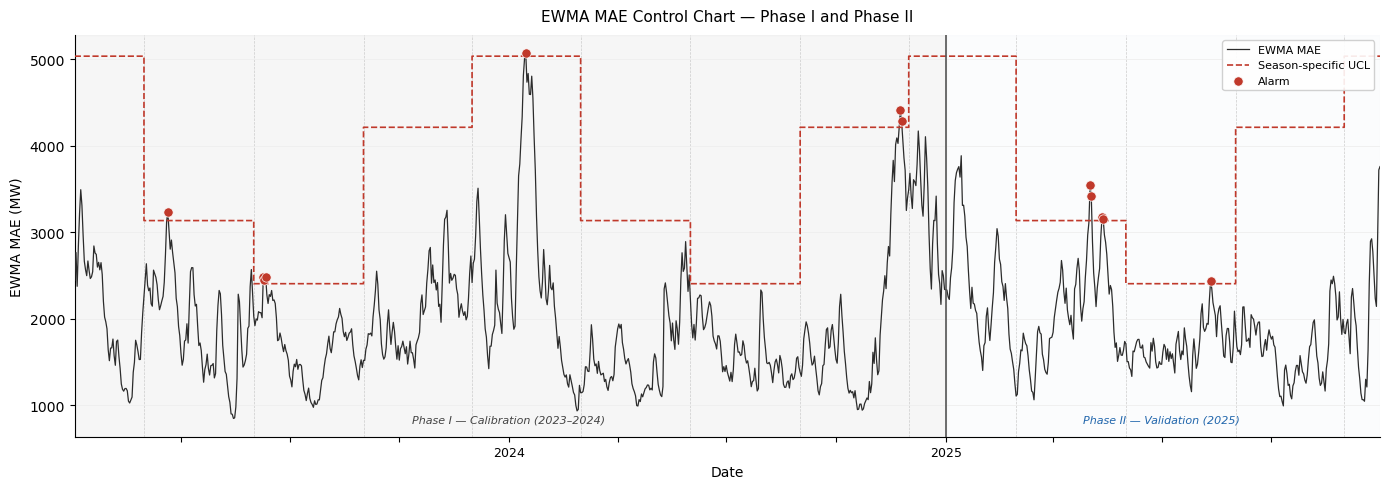

In [45]:

# =========================================================
#  Prepare Phase II data 2025-01-01 to 2025-12-31
# ========================================================= 

full_mae = daily_mae.loc["2023-01-01":"2025-12-31"].dropna() # ensure full calendar coverage
full_mae.index = pd.to_datetime(full_mae.index).tz_localize(None)

# season labels for the full calendar period (for UCL alignment and plotting)
full_season = full_mae.index.month.map(
    lambda m: "Winter" if m in [12,1,2]
    else "Spring" if m in [3,4,5]
    else "Summer" if m in [6,7,8]
    else "Autumn"
)
full_season = pd.Series(full_season.values, index=full_mae.index)

# =========================================================
# 1. Compute full EWMA path (init from Phase I mean)
# =========================================================
ewma_full = compute_ewma(full_mae.values, lam=LAM, init=init_mae)
ewma_full = pd.Series(ewma_full, index=full_mae.index)

# =========================================================
# 2. Align season-specific UCL (from Scheme A)
# =========================================================
ucl_full = full_season.map(ucl_mae_A)

# =========================================================
# 3. Alarm flags
# =========================================================
alarm_full = ewma_full > ucl_full

# =========================================================
# 4. Phase I / II boundary
# =========================================================
phase1_end = pd.Timestamp("2024-12-31")
phase2_start = pd.Timestamp("2025-01-01")

# =========================================================
# 5. Season boundary dates (for vertical lines)
# =========================================================
def get_season_boundaries(index):
    """Return dates where season changes."""
    months = pd.Series(index.month, index=index)
    season = months.map(
        lambda m: "Winter" if m in [12,1,2]
        else "Spring" if m in [3,4,5]
        else "Summer" if m in [6,7,8]
        else "Autumn"
    )
    boundaries = index[season != season.shift(1)].tolist()
    return boundaries[1:]  # skip first

season_boundaries = get_season_boundaries(full_mae.index)

# =========================================================
# 6. Plot
# =========================================================
fig, ax = plt.subplots(figsize=(14, 5))

# ── Phase I/II background shading ──
ax.axvspan(full_mae.index[0], phase2_start,
           alpha=0.04, color="#2c2c2c", zorder=0)
ax.axvspan(phase2_start, full_mae.index[-1],
           alpha=0.015, color="#2166ac", zorder=0)

# ── Season boundaries (light gray vertical lines, no labels) ──
for bd in season_boundaries:
    ax.axvline(bd, color="#cccccc", linewidth=0.5,
               linestyle="--", zorder=1)

# ── Phase I/II boundary ──
ax.axvline(phase2_start, color="#555555", linewidth=1.2,
           linestyle="-", zorder=4)

# ── EWMA line ──
ax.plot(ewma_full.index, ewma_full.values,
        color="#2c2c2c", linewidth=0.9,
        label="EWMA MAE", zorder=3)

# ── UCL as step line ──
ax.step(ucl_full.index, ucl_full.values,
        where="post",
        color="#c0392b", linewidth=1.2,
        linestyle="--", label="Season-specific UCL", zorder=3)

# ── Alarm points ──
alarm_dates = ewma_full.index[alarm_full]
alarm_vals  = ewma_full[alarm_full]
ax.scatter(alarm_dates, alarm_vals,
           color="#c0392b", s=45, zorder=5,
           label="Alarm", marker="o", edgecolors="white", linewidths=0.5)

# ── Phase I / II text at bottom ──
ymin, ymax = ax.get_ylim()
y_text = ymin + (ymax - ymin) * 0.03

ax.text(pd.Timestamp("2024-01-01"), y_text,
        "Phase I — Calibration (2023–2024)",
        fontsize=8, color="#444444",
        ha="center", va="bottom", style="italic")
ax.text(pd.Timestamp("2025-07-01"), y_text,
        "Phase II — Validation (2025)",
        fontsize=8, color="#2166ac",
        ha="center", va="bottom", style="italic")

# ── x-axis: quarterly ticks, year labels only ──
quarterly = pd.date_range("2023-01-01", "2026-01-01", freq="QS")
ax.set_xticks(quarterly)
ax.set_xticklabels([
    d.strftime("%Y") if d.month == 1 else ""
    for d in quarterly
], fontsize=9)

# ── Labels and formatting ──
ax.set_xlabel("Date", fontsize=10)
ax.set_ylabel("EWMA MAE (MW)", fontsize=10)
ax.set_title("EWMA MAE Control Chart — Phase I and Phase II",
             fontsize=11, fontweight="normal", pad=10)

ax.legend(loc="upper right", fontsize=8, framealpha=0.9,
          edgecolor="#cccccc")
ax.grid(axis="y", color="#eeeeee", linewidth=0.6, zorder=0)
ax.set_xlim(full_mae.index[0], full_mae.index[-1])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("ewma_mae_chart.pdf", dpi=300, bbox_inches="tight")
plt.savefig("ewma_mae_chart.png", dpi=300, bbox_inches="tight")
plt.show()


In [46]:
# Phase II alarm details of MAE chart (Scheme A)
phase2_alarms = pd.DataFrame({
    "EWMA_MAE": ewma_full,
    "UCL":      ucl_full,
    "Season":   full_season,
    "Alarm":    alarm_full
}, index=full_mae.index)

phase2_only = phase2_alarms.loc["2025-01-01":]
print(phase2_only[phase2_only["Alarm"] == True][["EWMA_MAE", "UCL", "Season"]])
print()

print(daily_mae.loc["2025-04-28":"2025-05-16"])
print()
print(daily_mae.loc["2025-08-07":"2025-08-15"])

            EWMA_MAE      UCL  Season
2025-05-02  3545.709 3136.456  Spring
2025-05-03  3422.037 3136.456  Spring
2025-05-12  3172.830 3136.456  Spring
2025-05-13  3152.287 3136.456  Spring
2025-08-11  2438.449 2406.318  Summer

2025-04-28   3586.248
2025-04-29   3475.824
2025-04-30   4143.452
2025-05-01   3682.142
2025-05-02   5282.391
2025-05-03   2927.346
2025-05-04    787.483
2025-05-05   1076.170
2025-05-06   1676.592
2025-05-07   1265.117
2025-05-08   3200.458
2025-05-09   2976.343
2025-05-10   3002.110
2025-05-11   4428.500
2025-05-12   4056.846
2025-05-13   3070.112
2025-05-14   2246.462
2025-05-15   2547.636
2025-05-16   2185.684
Name: error, dtype: float64

2025-08-07   2005.233
2025-08-08   2196.250
2025-08-09   1895.079
2025-08-10   3350.641
2025-08-11   3314.087
2025-08-12   1996.221
2025-08-13   1539.264
2025-08-14   1815.188
2025-08-15   1737.898
Name: error, dtype: float64


In [47]:
# =========================================================
#  Phase I input for ZBias chart
# =========================================================
phase1_zbias = baseline_df["Bias_standardized"].dropna().copy()
phase1_zbias_season = baseline_df.loc[phase1_zbias.index, "Season"].astype(str).copy()

print(f"Phase I ZBias sample: {len(phase1_zbias)} days")
print(f"Mean: {phase1_zbias.mean():.4f}, Std: {phase1_zbias.std():.4f}")
print(f"Min:  {phase1_zbias.min():.4f}, Max: {phase1_zbias.max():.4f}")

# =========================================================
# 1. Full-calendar EWMA path for ZBias
# =========================================================
init_zbias = 0.0  # zero-centered by construction

ewma_zbias_phase1 = compute_ewma(phase1_zbias.values, lam=LAM, init=init_zbias)

print(f"\nEWMA ZBias — mean: {ewma_zbias_phase1.mean():.4f}, "
      f"min: {ewma_zbias_phase1.min():.4f}, "
      f"max: {ewma_zbias_phase1.max():.4f}")

# =========================================================
# 2. Global MBB + common two-sided limits
# =========================================================
def mbb_global_common_limits(
    series, lam, init,
    block_length=21, B=5000,
    upper_q=0.995, lower_q=0.005,
    seed=42
):
    """
    Global MBB bootstrap for ZBias chart.
    Returns common two-sided control limits (not season-specific).

    Parameters
    ----------
    series      : np.ndarray, Phase I ZBias series in time order
    lam         : float, EWMA smoothing parameter
    init        : float, initial EWMA value E_0
    block_length: int, MBB block length
    B           : int, bootstrap replications
    upper_q     : float, upper quantile level (0.995)
    lower_q     : float, lower quantile level (0.005)
    seed        : int, random seed

    Returns
    -------
    ucl         : float, upper control limit
    lcl         : float, lower control limit
    all_paths   : np.ndarray, shape (B, T), bootstrap EWMA paths
    """
    rng = np.random.default_rng(seed)
    series = np.asarray(series, dtype=float)
    T = len(series)

    all_paths = np.empty((B, T), dtype=float)

    for b in range(B):
        boot = mbb_resample_path(series, block_length=block_length, rng=rng)
        all_paths[b] = compute_ewma(boot, lam=lam, init=init)

    ucl = np.quantile(all_paths.ravel(), upper_q)
    lcl = np.quantile(all_paths.ravel(), lower_q)

    return ucl, lcl, all_paths


# =========================================================
# 3. Main specification
# =========================================================
ucl_zbias, lcl_zbias, paths_zbias = mbb_global_common_limits(
    series=phase1_zbias.values,
    lam=LAM,
    init=init_zbias,
    block_length=BLOCK_LENGTH,
    B=B_REP,
    upper_q=0.995,
    lower_q=0.005,
    seed=SEED
)

print(f"\nZBias chart: common two-sided limits")
print(f"UCL: {ucl_zbias:.4f}")
print(f"LCL: {lcl_zbias:.4f}")
print(f"Symmetric: {abs(abs(ucl_zbias) - abs(lcl_zbias)) < 0.01}")

# =========================================================
# 4. Phase I alarm check
# =========================================================
alarm_upper_phase1 = ewma_zbias_phase1 > ucl_zbias
alarm_lower_phase1 = ewma_zbias_phase1 < lcl_zbias
alarm_zbias_phase1 = alarm_upper_phase1 | alarm_lower_phase1

print(f"\nPhase I ZBias alarm summary")
print(f"Upper alarms: {alarm_upper_phase1.sum()} / {len(ewma_zbias_phase1)}")
print(f"Lower alarms: {alarm_lower_phase1.sum()} / {len(ewma_zbias_phase1)}")
print(f"Total alarms: {alarm_zbias_phase1.sum()} / {len(ewma_zbias_phase1)}")
print(f"Total alarm rate: {alarm_zbias_phase1.mean()*100:.2f}%")

# =========================================================
# 5. Phase I alarm by season
# =========================================================
alarm_df_zbias = pd.DataFrame({
    "EWMA_ZBias": ewma_zbias_phase1,
    "UCL": ucl_zbias,
    "LCL": lcl_zbias,
    "Season": phase1_zbias_season.values,
    "Alarm_upper": alarm_upper_phase1,
    "Alarm_lower": alarm_lower_phase1,
    "Alarm": alarm_zbias_phase1
}, index=phase1_zbias.index)

summary_zbias = alarm_df_zbias.groupby("Season").agg(
    total=("Alarm", "count"),
    upper_alarms=("Alarm_upper", "sum"),
    lower_alarms=("Alarm_lower", "sum"),
    total_alarms=("Alarm", "sum"),
    alarm_rate=("Alarm", lambda x: f"{x.mean()*100:.2f}%")
).reindex(season_order)

print("\nPhase I ZBias alarm by season:")
print(summary_zbias)

Phase I ZBias sample: 727 days
Mean: -0.0000, Std: 0.9979
Min:  -3.4572, Max: 2.4554

EWMA ZBias — mean: -0.0007, min: -1.6726, max: 1.6883

ZBias chart: common two-sided limits
UCL: 1.5623
LCL: -1.3669
Symmetric: False

Phase I ZBias alarm summary
Upper alarms: 4 / 727
Lower alarms: 4 / 727
Total alarms: 8 / 727
Total alarm rate: 1.10%

Phase I ZBias alarm by season:
        total  upper_alarms  lower_alarms  total_alarms alarm_rate
Season                                                            
Winter    179             1             0             1      0.56%
Spring    182             0             0             0      0.00%
Summer    184             0             0             0      0.00%
Autumn    182             3             4             7      3.85%


In [48]:
# Phase I ZBias alarms details
phase1_zbias_alarms = alarm_df_zbias[alarm_df_zbias["Alarm"] == True]
print(phase1_zbias_alarms[["EWMA_ZBias", "UCL", "LCL", "Alarm_upper", "Alarm_lower", "Season"]])



for date in phase1_zbias_alarms.index:
    start = date - pd.Timedelta(days=5)
    end = date + pd.Timedelta(days=5)
    print(f"\nAlarm: {date.date()}  Season: {phase1_zbias_alarms.loc[date, 'Season']}")
    print(f"EWMA_ZBias: {phase1_zbias_alarms.loc[date, 'EWMA_ZBias']:.4f}")
    print(baseline_df.loc[start:end, ["Bias", "Bias_standardized", "Season"]])

            EWMA_ZBias   UCL    LCL  Alarm_upper  Alarm_lower  Season
2024-01-15       1.595 1.562 -1.367         True        False  Winter
2024-09-22      -1.476 1.562 -1.367        False         True  Autumn
2024-09-23      -1.635 1.562 -1.367        False         True  Autumn
2024-09-24      -1.673 1.562 -1.367        False         True  Autumn
2024-09-25      -1.547 1.562 -1.367        False         True  Autumn
2024-11-23       1.570 1.562 -1.367         True        False  Autumn
2024-11-24       1.688 1.562 -1.367         True        False  Autumn
2024-11-25       1.616 1.562 -1.367         True        False  Autumn

Alarm: 2024-01-15  Season: Winter
EWMA_ZBias: 1.5945
               Bias  Bias_standardized  Season
2024-01-10 4337.730              1.416  Winter
2024-01-11 5232.586              1.743  Winter
2024-01-12 5369.432              1.793  Winter
2024-01-13 6721.570              2.287  Winter
2024-01-14 5819.864              1.957  Winter
2024-01-15 5305.911              1

Full ZBias series: 1089 days
Range: -3.457 to 2.455

Phase II ZBias alarms: 18
            EWMA_ZBias   UCL    LCL  Alarm_upper  Alarm_lower  Season
2025-05-02      -1.463 1.562 -1.367        False         True  Spring
2025-05-03      -1.397 1.562 -1.367        False         True  Spring
2025-09-07      -1.625 1.562 -1.367        False         True  Autumn
2025-09-08      -1.703 1.562 -1.367        False         True  Autumn
2025-09-09      -1.594 1.562 -1.367        False         True  Autumn
2025-09-10      -1.480 1.562 -1.367        False         True  Autumn
2025-09-11      -1.515 1.562 -1.367        False         True  Autumn
2025-09-12      -1.580 1.562 -1.367        False         True  Autumn
2025-09-13      -1.561 1.562 -1.367        False         True  Autumn
2025-09-14      -1.811 1.562 -1.367        False         True  Autumn
2025-09-15      -1.780 1.562 -1.367        False         True  Autumn
2025-09-16      -1.622 1.562 -1.367        False         True  Autumn
2025-09-17 

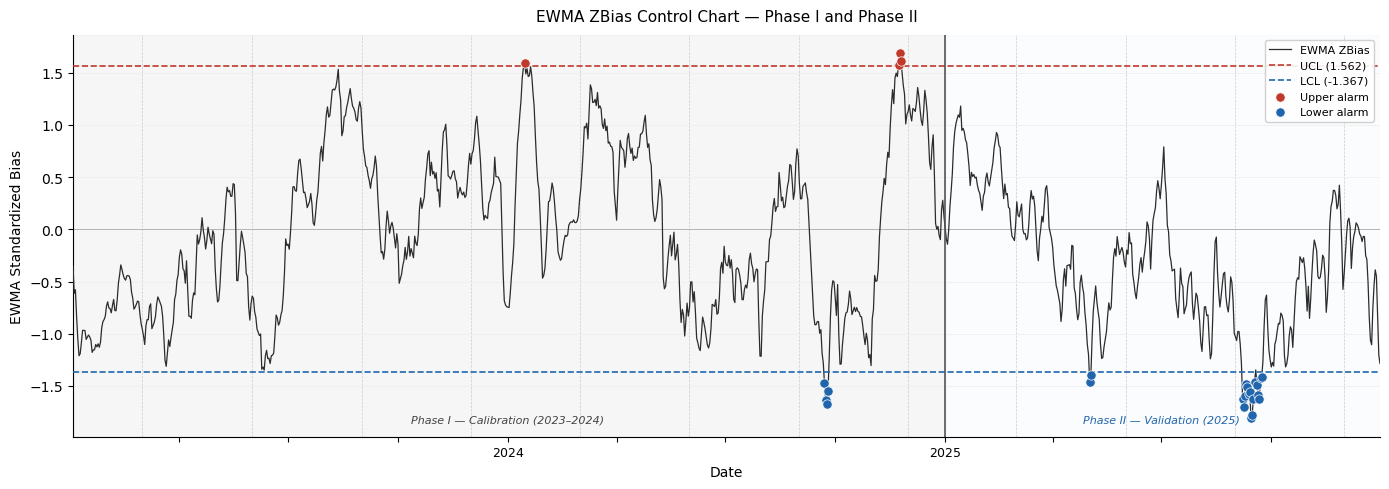

In [49]:
# =========================================================
# 0. Prepare full ZBias series (Phase I + Phase II)
# =========================================================

# Phase I seasonal parameters for standardization
# NOTE: same computation as Cell 25/27; repeated here for local clarity
# and to ensure this cell can run independently of Cell 25.
bias_season_mean = baseline_df.groupby("Season")["Bias"].mean()
bias_season_std  = baseline_df.groupby("Season")["Bias"].std()

# Build full 2023-2025 daily bias series
full_bias = daily_bias.loc["2023-01-01":"2025-12-31"].dropna()
full_bias.index = pd.to_datetime(full_bias.index).tz_localize(None)

# Assign season labels
full_bias_season = pd.Series(
    full_bias.index.month.map(
        lambda m: "Winter" if m in [12,1,2]
        else "Spring" if m in [3,4,5]
        else "Summer" if m in [6,7,8]
        else "Autumn"
    ).values,
    index=full_bias.index
)

# 2025-01-01 to 2025-12-31 ZBias series, standardized by Phase I seasonal parameters
full_zbias = (
    full_bias - full_bias_season.map(bias_season_mean)
) / full_bias_season.map(bias_season_std)

print(f"Full ZBias series: {len(full_zbias)} days")
print(f"Range: {full_zbias.min():.3f} to {full_zbias.max():.3f}")

# =========================================================
# 1. Full-calendar EWMA path
# =========================================================
ewma_zbias_full = compute_ewma(full_zbias.values, lam=LAM, init=init_zbias)
ewma_zbias_full = pd.Series(ewma_zbias_full, index=full_zbias.index)

# =========================================================
# 2. Alarm flags
# =========================================================
alarm_upper_full = ewma_zbias_full > ucl_zbias
alarm_lower_full = ewma_zbias_full < lcl_zbias
alarm_zbias_full = alarm_upper_full | alarm_lower_full

# =========================================================
# 3. Phase II alarm summary
# =========================================================
phase2_zbias = pd.DataFrame({
    "EWMA_ZBias": ewma_zbias_full,
    "UCL": ucl_zbias,
    "LCL": lcl_zbias,
    "Season": full_bias_season,
    "Alarm_upper": alarm_upper_full,
    "Alarm_lower": alarm_lower_full,
    "Alarm": alarm_zbias_full
}, index=full_zbias.index)

phase2_only_zbias = phase2_zbias.loc["2025-01-01":]
phase2_alarms_zbias = phase2_only_zbias[phase2_only_zbias["Alarm"]]

print(f"\nPhase II ZBias alarms: {len(phase2_alarms_zbias)}")
if len(phase2_alarms_zbias) > 0:
    print(phase2_alarms_zbias[["EWMA_ZBias", "UCL", "LCL",
                                "Alarm_upper", "Alarm_lower", "Season"]])

# =========================================================
# 4. Plot
# =========================================================
fig, ax = plt.subplots(figsize=(14, 5))

# ── Phase I/II background shading ──
ax.axvspan(full_zbias.index[0], phase2_start,
           alpha=0.04, color="#2c2c2c", zorder=0)
ax.axvspan(phase2_start, full_zbias.index[-1],
           alpha=0.015, color="#2166ac", zorder=0)

# ── Season boundaries ──
season_boundaries_z = get_season_boundaries(full_zbias.index)
for bd in season_boundaries_z:
    ax.axvline(bd, color="#cccccc", linewidth=0.5,
               linestyle="--", zorder=1)

# ── Phase I/II boundary ──
ax.axvline(phase2_start, color="#555555", linewidth=1.2,
           linestyle="-", zorder=4)

# ── Zero reference line ──
ax.axhline(0, color="#aaaaaa", linewidth=0.6,
           linestyle="-", zorder=2)

# ── EWMA line ──
ax.plot(ewma_zbias_full.index, ewma_zbias_full.values,
        color="#2c2c2c", linewidth=0.9,
        label="EWMA ZBias", zorder=3)

# ── UCL and LCL as horizontal lines ──
ax.axhline(ucl_zbias, color="#c0392b", linewidth=1.2,
           linestyle="--", label=f"UCL ({ucl_zbias:.3f})", zorder=3)
ax.axhline(lcl_zbias, color="#2166ac", linewidth=1.2,
           linestyle="--", label=f"LCL ({lcl_zbias:.3f})", zorder=3)

# ── Upper alarms ──
upper_dates = ewma_zbias_full.index[alarm_upper_full]
upper_vals  = ewma_zbias_full[alarm_upper_full]
ax.scatter(upper_dates, upper_vals,
           color="#c0392b", s=45, zorder=5,
           marker="o", edgecolors="white", linewidths=0.5,
           label="Upper alarm")

# ── Lower alarms ──
lower_dates = ewma_zbias_full.index[alarm_lower_full]
lower_vals  = ewma_zbias_full[alarm_lower_full]
ax.scatter(lower_dates, lower_vals,
           color="#2166ac", s=45, zorder=5,
           marker="o", edgecolors="white", linewidths=0.5,
           label="Lower alarm")

# ── Phase I/II text at bottom ──
ymin, ymax = ax.get_ylim()
y_text = ymin + (ymax - ymin) * 0.03

ax.text(pd.Timestamp("2024-01-01"), y_text,
        "Phase I — Calibration (2023–2024)",
        fontsize=8, color="#444444",
        ha="center", va="bottom", style="italic")
ax.text(pd.Timestamp("2025-07-01"), y_text,
        "Phase II — Validation (2025)",
        fontsize=8, color="#2166ac",
        ha="center", va="bottom", style="italic")

# ── x-axis ──
quarterly = pd.date_range("2023-01-01", "2026-01-01", freq="QS")
ax.set_xticks(quarterly)
ax.set_xticklabels([
    d.strftime("%Y") if d.month == 1 else ""
    for d in quarterly
], fontsize=9)

# ── Labels and formatting ──
ax.set_xlabel("Date", fontsize=10)
ax.set_ylabel("EWMA Standardized Bias", fontsize=10)
ax.set_title("EWMA ZBias Control Chart — Phase I and Phase II",
             fontsize=11, fontweight="normal", pad=10)

ax.legend(loc="upper right", fontsize=8,
          framealpha=0.9, edgecolor="#cccccc")
ax.grid(axis="y", color="#eeeeee", linewidth=0.6, zorder=0)
ax.set_xlim(full_zbias.index[0], full_zbias.index[-1])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("ewma_zbias_chart.pdf", dpi=300, bbox_inches="tight")
plt.savefig("ewma_zbias_chart.png", dpi=300, bbox_inches="tight")
plt.show()



In [50]:
# Phase II ZBias alarms details
for date in phase2_only_zbias[phase2_only_zbias["Alarm"] == True].index:
    start = date - pd.Timedelta(days=5)
    end = date + pd.Timedelta(days=5)
    print(f"\n{'='*50}")
    print(f"Alarm: {date.date()}  Season: {phase2_only_zbias.loc[date, 'Season']}")
    print(f"EWMA_ZBias: {phase2_only_zbias.loc[date, 'EWMA_ZBias']:.4f}  LCL: {phase2_only_zbias.loc[date, 'LCL']:.4f}")
    print(daily_bias.loc[start:end])



Alarm: 2025-05-02  Season: Spring
EWMA_ZBias: -1.4631  LCL: -1.3669
2025-04-27   -2473.781
2025-04-28   -3580.940
2025-04-29   -3369.642
2025-04-30   -4143.452
2025-05-01   -3682.142
2025-05-02   -5282.391
2025-05-03   -2927.346
2025-05-04    -366.345
2025-05-05    -595.896
2025-05-06   -1283.189
2025-05-07   -1124.334
Name: error, dtype: float64

Alarm: 2025-05-03  Season: Spring
EWMA_ZBias: -1.3971  LCL: -1.3669
2025-04-28   -3580.940
2025-04-29   -3369.642
2025-04-30   -4143.452
2025-05-01   -3682.142
2025-05-02   -5282.391
2025-05-03   -2927.346
2025-05-04    -366.345
2025-05-05    -595.896
2025-05-06   -1283.189
2025-05-07   -1124.334
2025-05-08   -3200.458
Name: error, dtype: float64

Alarm: 2025-09-07  Season: Autumn
EWMA_ZBias: -1.6253  LCL: -1.3669
2025-09-02    -719.000
2025-09-03     305.549
2025-09-04    -334.760
2025-09-05   -1374.171
2025-09-06   -2152.520
2025-09-07   -3883.432
2025-09-08   -2149.996
2025-09-09    -629.727
2025-09-10    -390.291
2025-09-11   -1512.779
2

In [51]:
# =========================================================
# 0. Prepare stress period data (2020-2022)
# =========================================================
stress_mae = daily_mae.loc["2020-01-01":"2022-12-31"].dropna().copy()
stress_mae.index = pd.to_datetime(stress_mae.index)

stress_bias = daily_bias.loc["2020-01-01":"2022-12-31"].dropna().copy()
stress_bias.index = pd.to_datetime(stress_bias.index)

# align indices
common_idx = stress_mae.index.intersection(stress_bias.index)
stress_mae = stress_mae.loc[common_idx].copy()
stress_bias = stress_bias.loc[common_idx].copy()

# season labels
stress_season = pd.Series(
    stress_mae.index.month.map(
        lambda m: "Winter" if m in [12, 1, 2]
        else "Spring" if m in [3, 4, 5]
        else "Summer" if m in [6, 7, 8]
        else "Autumn"
    ),
    index=stress_mae.index
)

# sanity checks for Phase I standardization parameters
if bias_season_std.isna().any() or (bias_season_std <= 0).any():
    raise ValueError("Invalid seasonal std from Phase I.")

# standardize Bias using Phase I seasonal parameters
stress_zbias = (
    stress_bias - stress_season.map(bias_season_mean)
) / stress_season.map(bias_season_std)

if not np.isfinite(stress_zbias).all():
    raise ValueError("Non-finite values found in stress_zbias after standardization.")

print(f"Stress period MAE:   {len(stress_mae)} days")
print(f"Stress period ZBias: {len(stress_zbias)} days")
print(f"\nStress MAE range:   {stress_mae.min():.1f} to {stress_mae.max():.1f} MW")
print(f"Stress ZBias range: {stress_zbias.min():.3f} to {stress_zbias.max():.3f}")

Stress period MAE:   1086 days
Stress period ZBias: 1086 days

Stress MAE range:   336.7 to 8722.8 MW
Stress ZBias range: -5.096 to 5.109


In [52]:
# =========================================================
# 0. Index alignment check
# =========================================================
assert stress_mae.index.equals(stress_zbias.index), \
    "stress_mae and stress_zbias indices do not match"
assert stress_mae.index.equals(stress_season.index), \
    "stress_mae and stress_season indices do not match"

# =========================================================
# 1. EWMA paths for stress period
# =========================================================
ewma_stress_mae   = compute_ewma(stress_mae.values,   LAM, init_mae)
ewma_stress_zbias = compute_ewma(stress_zbias.values, LAM, 0.0)

ewma_stress_mae   = pd.Series(ewma_stress_mae,   index=stress_mae.index)
ewma_stress_zbias = pd.Series(ewma_stress_zbias, index=stress_zbias.index)

# =========================================================
# 2. Align UCLs and check NaN
# =========================================================
ucl_stress_mae = stress_season.map(ucl_mae_A)

if ucl_stress_mae.isna().any():
    missing = stress_season[ucl_stress_mae.isna()].unique()
    raise ValueError(f"Missing MAE UCL for seasons: {missing}")

# MAE alarms
alarm_stress_mae = ewma_stress_mae > ucl_stress_mae

# ZBias alarms
alarm_stress_upper = ewma_stress_zbias > ucl_zbias
alarm_stress_lower = ewma_stress_zbias < lcl_zbias
alarm_stress_zbias = alarm_stress_upper | alarm_stress_lower

# =========================================================
# 3. Build stress DataFrame
# =========================================================
alarm_df_stress = pd.DataFrame({
    "Year":        stress_mae.index.year,
    "Season":      stress_season.values,
    "EWMA_MAE":    ewma_stress_mae.values,
    "UCL_MAE":     ucl_stress_mae.values,
    "Alarm_MAE":   alarm_stress_mae.values,
    "EWMA_ZBias":  ewma_stress_zbias.values,
    "Alarm_Upper": alarm_stress_upper.values,
    "Alarm_Lower": alarm_stress_lower.values,
    "Alarm_ZBias": alarm_stress_zbias.values,
}, index=stress_mae.index)

# =========================================================
# 4. Yearly summary
# =========================================================
yearly = alarm_df_stress.groupby("Year").agg(
    total        = ("Alarm_MAE",   "count"),
    MAE_alarms   = ("Alarm_MAE",   "sum"),
    MAE_rate     = ("Alarm_MAE",   "mean"),
    ZBias_alarms = ("Alarm_ZBias", "sum"),
    ZBias_rate   = ("Alarm_ZBias", "mean"),
    Upper_alarms = ("Alarm_Upper", "sum"),
    Lower_alarms = ("Alarm_Lower", "sum"),
).reindex([2020, 2021, 2022])

yearly["MAE_rate_pct"]   = (yearly["MAE_rate"]   * 100).round(1)
yearly["ZBias_rate_pct"] = (yearly["ZBias_rate"] * 100).round(1)

print("=" * 60)
print("Stress period alarm summary by year")
print("=" * 60)
print(yearly[["total", "MAE_alarms", "MAE_rate_pct",
              "ZBias_alarms", "ZBias_rate_pct",
              "Upper_alarms", "Lower_alarms"]])

# =========================================================
# 5. Stress vs Phase I comparison
# =========================================================
phase1_mae_rate   = mae_alarm_A.mean()
phase1_zbias_rate = alarm_zbias_phase1.mean()

stress_mae_rate   = alarm_stress_mae.mean()
stress_zbias_rate = alarm_stress_zbias.mean()

print("\n" + "=" * 60)
print("Overall alarm rates: stress period vs Phase I")
print("=" * 60)
print(f"MAE   — stress: {stress_mae_rate*100:.1f}%  "
      f"| Phase I: {phase1_mae_rate*100:.1f}%")
print(f"ZBias — stress: {stress_zbias_rate*100:.1f}%  "
      f"| Phase I: {phase1_zbias_rate*100:.1f}%")

Stress period alarm summary by year
      total  MAE_alarms  MAE_rate_pct  ZBias_alarms  ZBias_rate_pct  \
Year                                                                  
2020    364           0         0.000            12           3.300   
2021    362          51        14.100            77          21.300   
2022    360          27         7.500            94          26.100   

      Upper_alarms  Lower_alarms  
Year                              
2020            12             0  
2021            77             0  
2022            14            80  

Overall alarm rates: stress period vs Phase I
MAE   — stress: 7.2%  | Phase I: 1.0%
ZBias — stress: 16.9%  | Phase I: 1.1%


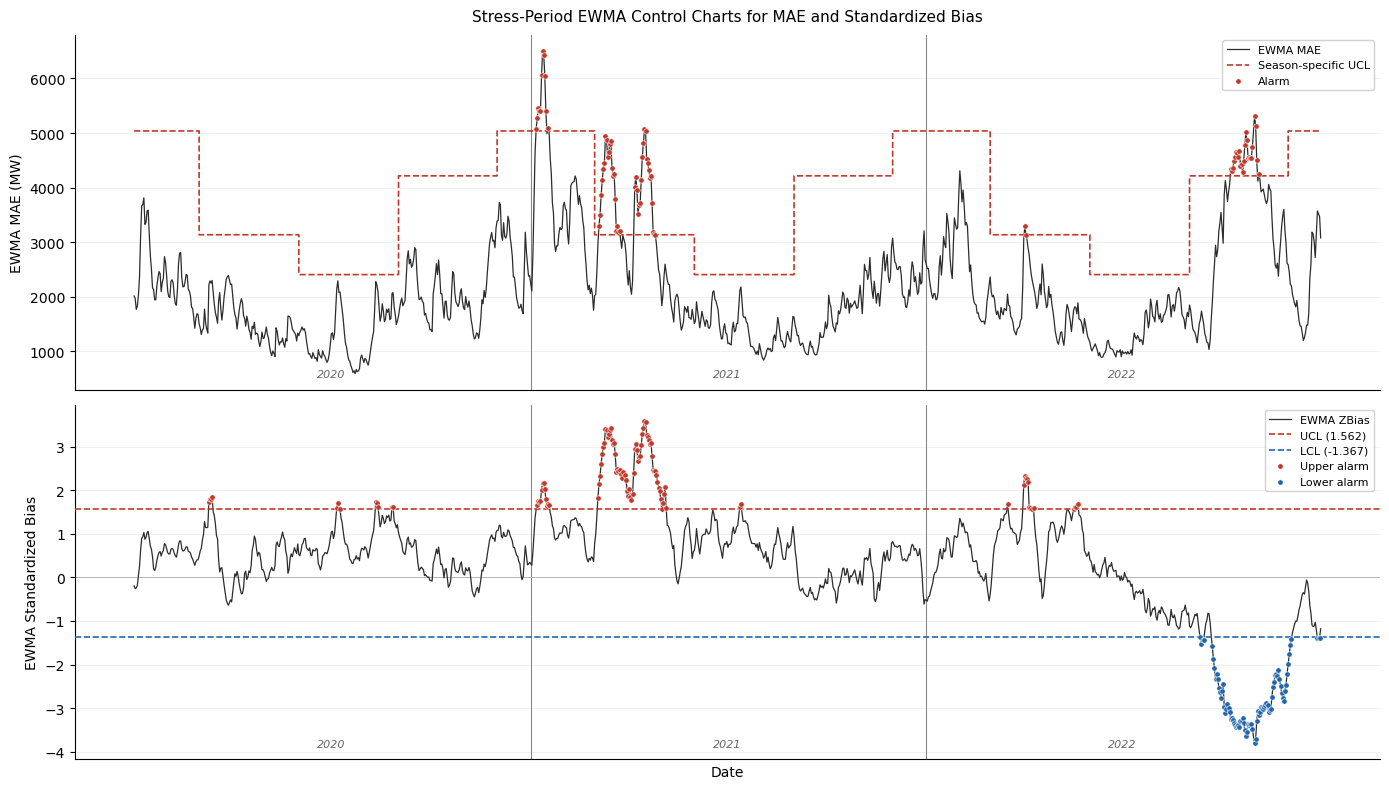

In [53]:

# =========================================================
# Stress period control charts: MAE + ZBias side by side
# =========================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Year boundaries
year_boundaries = [
    pd.Timestamp("2021-01-01"),
    pd.Timestamp("2022-01-01")
]

# =========================================================
# Panel 1: MAE chart
# =========================================================
ax1 = axes[0]

# Year boundaries
for yb in year_boundaries:
    ax1.axvline(yb, color="#888888", linewidth=0.8,
                linestyle="-", zorder=2)

# EWMA MAE
ax1.plot(
    ewma_stress_mae.index, ewma_stress_mae.values,
    color="#2c2c2c", linewidth=0.9,
    label="EWMA MAE", zorder=3
)

# Season-specific UCL
ax1.step(
    ucl_stress_mae.index, ucl_stress_mae.values,
    where="post",
    color="#c0392b", linewidth=1.2,
    linestyle="--",
    label="Season-specific UCL", zorder=3
)

# Alarm points
mae_alarm_dates = ewma_stress_mae.index[alarm_stress_mae]
mae_alarm_vals = ewma_stress_mae[alarm_stress_mae]
ax1.scatter(
    mae_alarm_dates, mae_alarm_vals,
    color="#c0392b", s=15, zorder=5,
    marker="o", edgecolors="white", linewidths=0.4,
    label="Alarm"
)

# Labels and style
ax1.set_ylabel("EWMA MAE (MW)", fontsize=10)
ax1.set_title(
    "Stress-Period EWMA Control Charts for MAE and Standardized Bias",
    fontsize=11, fontweight="normal", pad=10
)
ax1.legend(loc="upper right", fontsize=8,
           framealpha=0.9, edgecolor="#cccccc")
ax1.grid(axis="y", color="#eeeeee", linewidth=0.6, zorder=0)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Add year labels after all elements are drawn
ymin1, ymax1 = ax1.get_ylim()
for year, xpos in [(2020, "2020-07-01"),
                   (2021, "2021-07-01"),
                   (2022, "2022-07-01")]:
    ax1.text(
        pd.Timestamp(xpos),
        ymin1 + (ymax1 - ymin1) * 0.03,
        str(year),
        fontsize=8, color="#666666",
        ha="center", va="bottom", style="italic"
    )

# =========================================================
# Panel 2: ZBias chart
# =========================================================
ax2 = axes[1]

# Year boundaries
for yb in year_boundaries:
    ax2.axvline(yb, color="#888888", linewidth=0.8,
                linestyle="-", zorder=2)

# Zero reference line
ax2.axhline(0, color="#aaaaaa", linewidth=0.6,
            linestyle="-", zorder=2)

# EWMA ZBias
ax2.plot(
    ewma_stress_zbias.index, ewma_stress_zbias.values,
    color="#2c2c2c", linewidth=0.9,
    label="EWMA ZBias", zorder=3
)

# UCL and LCL
ax2.axhline(
    ucl_zbias, color="#c0392b", linewidth=1.2,
    linestyle="--", label=f"UCL ({ucl_zbias:.3f})", zorder=3
)
ax2.axhline(
    lcl_zbias, color="#2166ac", linewidth=1.2,
    linestyle="--", label=f"LCL ({lcl_zbias:.3f})", zorder=3
)

# Upper alarms
upper_stress_dates = ewma_stress_zbias.index[alarm_stress_upper]
upper_stress_vals = ewma_stress_zbias[alarm_stress_upper]
ax2.scatter(
    upper_stress_dates, upper_stress_vals,
    color="#c0392b", s=15, zorder=5,
    marker="o", edgecolors="white", linewidths=0.4,
    label="Upper alarm"
)

# Lower alarms
lower_stress_dates = ewma_stress_zbias.index[alarm_stress_lower]
lower_stress_vals = ewma_stress_zbias[alarm_stress_lower]
ax2.scatter(
    lower_stress_dates, lower_stress_vals,
    color="#2166ac", s=15, zorder=5,
    marker="o", edgecolors="white", linewidths=0.4,
    label="Lower alarm"
)

# Labels and style
ax2.set_ylabel("EWMA Standardized Bias", fontsize=10)
ax2.set_xlabel("Date", fontsize=10)
ax2.legend(loc="upper right", fontsize=8,
           framealpha=0.9, edgecolor="#cccccc")
ax2.grid(axis="y", color="#eeeeee", linewidth=0.6, zorder=0)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# Add year labels after all elements are drawn
ymin2, ymax2 = ax2.get_ylim()
for year, xpos in [(2020, "2020-07-01"),
                   (2021, "2021-07-01"),
                   (2022, "2022-07-01")]:
    ax2.text(
        pd.Timestamp(xpos),
        ymin2 + (ymax2 - ymin2) * 0.03,
        str(year),
        fontsize=8, color="#666666",
        ha="center", va="bottom", style="italic"
    )

# =========================================================
# Shared x-axis
# =========================================================
ax2.set_xticks([])

plt.tight_layout()
plt.savefig("stress_test_chart_clean.pdf", dpi=300, bbox_inches="tight")
plt.savefig("stress_test_chart_clean.png", dpi=300, bbox_inches="tight")
plt.show()



In [54]:
# =========================================================
# A. 2021 ZBias representative upper-side cluster
# =========================================================
#  2021-03  2021-05  Bias、EWMA_ZBias and alarms aligned together for inspection

cluster_2021 = alarm_df_stress.loc["2021-03-01":"2021-05-31", [
    "EWMA_ZBias", "Alarm_Upper", "Alarm_Lower", "Alarm_ZBias"
]].copy()

cluster_2021["Bias_raw"] = stress_bias.loc["2021-03-01":"2021-05-31"]

print("=" * 80)
print("2021 representative ZBias cluster (March–May 2021)")
print("=" * 80)
print(cluster_2021)

#  upper alarms
cluster_2021_upper = cluster_2021[cluster_2021["Alarm_Upper"]].copy()

print("\n" + "=" * 80)
print("2021 upper-side ZBias alarms only")
print("=" * 80)
print(cluster_2021_upper)

# =========================================================
# B. Phase I MAE alarms ranked by marginal exceedance
# =========================================================
# excess = EWMA_MAE - UCL，most negative excess = most marginal alarm

phase1_mae_alarms = alarm_df_A[alarm_df_A["Alarm"] == True].copy()
phase1_mae_alarms["excess"] = (
    phase1_mae_alarms["EWMA_MAE"] - phase1_mae_alarms["UCL"]
)

print("\n" + "=" * 80)
print("Phase I MAE alarms ranked by exceedance size")
print("=" * 80)
print(
    phase1_mae_alarms[["EWMA_MAE", "UCL", "Season", "excess"]]
    .sort_values("excess")
)

# =========================================================
# C. Inspect the most marginal Phase I MAE alarm
# =========================================================
#  5 day original MAE

edge_date = phase1_mae_alarms.sort_values("excess").index[0]

print("\n" + "=" * 80)
print(f"Most marginal Phase I MAE alarm: {edge_date}")
print("=" * 80)

# alarm details
print(phase1_mae_alarms.loc[[edge_date], ["EWMA_MAE", "UCL", "Season", "excess"]])

# window around the alarm date
window = 5
mae_window = daily_mae.loc[
    edge_date - pd.Timedelta(days=window) : edge_date + pd.Timedelta(days=window)
].copy()

print("\nOriginal MAE window around the most marginal alarm")
print(mae_window)

# =========================================================
# D. Optional: inspect the top 3 most marginal alarms
# =========================================================

top3_edge_dates = phase1_mae_alarms.sort_values("excess").index[:3]

for dt in top3_edge_dates:
    print("\n" + "=" * 80)
    print(f"MAE window around marginal alarm: {dt}")
    print("=" * 80)
    print(
        phase1_mae_alarms.loc[[dt], ["EWMA_MAE", "UCL", "Season", "excess"]]
    )
    print(
        daily_mae.loc[
            dt - pd.Timedelta(days=window) : dt + pd.Timedelta(days=window)
        ]
    )

2021 representative ZBias cluster (March–May 2021)
            EWMA_ZBias  Alarm_Upper  Alarm_Lower  Alarm_ZBias  Bias_raw
2021-03-01       0.774        False        False        False  3100.635
2021-03-02       0.990        False        False        False  2128.790
2021-03-03       1.380        False        False        False  3971.138
2021-03-04       1.823         True        False         True  5076.057
2021-03-05       2.132         True        False         True  4689.639
...                ...          ...          ...          ...       ...
2021-05-27       1.287        False        False        False   609.541
2021-05-28       0.964        False        False        False -1567.183
2021-05-29       0.754        False        False        False -1149.916
2021-05-30       0.434        False        False        False -2443.586
2021-05-31       0.582        False        False        False   979.791

[91 rows x 5 columns]

2021 upper-side ZBias alarms only
            EWMA_ZBias  Ala

In [55]:
# =========================================================
# sensitivity analysis function for MAE and ZBias schemes
# =========================================================

def run_mae_scheme(lam, block_length, B=5000, seed=42, quantile=0.995):

    # ── Phase I calibration ──
    ucl, _, _ = mbb_by_season_ucl(
        series=phase1_mae.values,
        seasons=phase1_season.values,
        lam=lam, init=init_mae,
        block_length=block_length,
        B=B, quantile=quantile, seed=seed
    )

    # ── Phase I alarms ──
    ewma_p1  = compute_ewma(phase1_mae.values, lam, init_mae)
    ucl_p1   = phase1_season.map(ucl).to_numpy()
    alarm_p1 = ewma_p1 > ucl_p1
    rate_p1  = alarm_p1.mean()

    # ── Phase II alarms (full calendar) ──
    ewma_full_arr  = compute_ewma(full_mae.values, lam, init_mae)
    ucl_full_arr   = full_season.map(ucl).to_numpy()
    alarm_full_arr = ewma_full_arr > ucl_full_arr

    phase2_mask = (full_mae.index >= pd.Timestamp("2025-01-01"))
    rate_p2     = alarm_full_arr[phase2_mask].mean()

    # representative event checks
    def check_event(index, arr, date_str):
        dt = pd.Timestamp(date_str)
        if dt in index:
            return bool(arr[index.get_loc(dt)])
        return np.nan

    event_2024_11_24 = check_event(
        full_mae.index, alarm_full_arr, "2024-11-24")
    event_2025_05_02 = check_event(
        full_mae.index, alarm_full_arr, "2025-05-02")

    # ── Stress alarms ──
    ewma_stress  = compute_ewma(stress_mae.values, lam, init_mae)
    ucl_stress   = stress_season.map(ucl).to_numpy()
    alarm_stress = ewma_stress > ucl_stress
    rate_stress  = alarm_stress.mean()

    return {
        "UCL_Winter":        round(ucl.get("Winter", np.nan), 1),
        "UCL_Spring":        round(ucl.get("Spring", np.nan), 1),
        "UCL_Summer":        round(ucl.get("Summer", np.nan), 1),
        "UCL_Autumn":        round(ucl.get("Autumn", np.nan), 1),
        "PhaseI_rate":       round(rate_p1   * 100, 2),
        "PhaseII_rate":      round(rate_p2   * 100, 2),
        "Stress_rate":       round(rate_stress * 100, 2),
        "Event_2024_11_24":  event_2024_11_24,
        "Event_2025_05_02":  event_2025_05_02,
    }


def run_zbias_scheme(lam, block_length, B=5000, seed=42,
                     upper_q=0.995, lower_q=0.005):

    # ── Phase I calibration ──
    ucl, lcl, _ = mbb_global_common_limits(
        series=phase1_zbias.values,
        lam=lam, init=0.0,
        block_length=block_length,
        B=B, upper_q=upper_q, lower_q=lower_q, seed=seed
    )

    # ── Phase I alarms ──
    ewma_p1  = compute_ewma(phase1_zbias.values, lam, 0.0)
    alarm_p1 = (ewma_p1 > ucl) | (ewma_p1 < lcl)
    rate_p1  = alarm_p1.mean()

    # ── Phase II alarms ──
    ewma_full_z  = compute_ewma(full_zbias.values, lam, 0.0)
    alarm_full_z = (ewma_full_z > ucl) | (ewma_full_z < lcl)
    phase2_mask  = (full_zbias.index >= pd.Timestamp("2025-01-01"))
    rate_p2      = alarm_full_z[phase2_mask].mean()

    # representative event checks
    def check_event(index, arr, date_str):
        dt = pd.Timestamp(date_str)
        if dt in index:
            return bool(arr[index.get_loc(dt)])
        return np.nan

    event_2025_09_07 = check_event(
        full_zbias.index, alarm_full_z, "2025-09-07")

    # ── Stress alarms ──
    ewma_stress_z  = compute_ewma(stress_zbias.values, lam, 0.0)
    alarm_stress_z = (ewma_stress_z > ucl) | (ewma_stress_z < lcl)
    rate_stress    = alarm_stress_z.mean()

    event_2021_03_04 = check_event(
        stress_zbias.index, alarm_stress_z, "2021-03-04")

    return {
        "UCL":               round(ucl, 4),
        "LCL":               round(lcl, 4),
        "PhaseI_rate":       round(rate_p1   * 100, 2),
        "PhaseII_rate":      round(rate_p2   * 100, 2),
        "Stress_rate":       round(rate_stress * 100, 2),
        "Event_2025_09_07":  event_2025_09_07,
        "Event_2021_03_04":  event_2021_03_04,
    }


# =========================================================
# Round 1: λ sensitivity (block_length=21)
# =========================================================
print("=" * 70)
print("Round 1: λ sensitivity  (block_length = 21)")
print("=" * 70)

lam_grid = [0.1, 0.2, 0.3]
mae_results_lam   = {}
zbias_results_lam = {}

for lam in lam_grid:
    print(f"  Running λ = {lam} ...")
    mae_results_lam[lam]   = run_mae_scheme(lam,   block_length=21)
    zbias_results_lam[lam] = run_zbias_scheme(lam, block_length=21)

mae_lam_df   = pd.DataFrame(mae_results_lam).T
zbias_lam_df = pd.DataFrame(zbias_results_lam).T
mae_lam_df.index.name   = "lambda"
zbias_lam_df.index.name = "lambda"

print("\nMAE chart — λ sensitivity")
print(mae_lam_df.to_string())
print("\nZBias chart — λ sensitivity")
print(zbias_lam_df.to_string())

# =========================================================
# Round 2: block length sensitivity (λ=0.2)
# =========================================================
print("\n" + "=" * 70)
print("Round 2: block length sensitivity  (λ = 0.2)")
print("=" * 70)

bl_grid = [7, 14, 21]
mae_results_bl   = {}
zbias_results_bl = {}

for bl in bl_grid:
    print(f"  Running block_length = {bl} ...")
    mae_results_bl[bl]   = run_mae_scheme(lam=0.2,   block_length=bl)
    zbias_results_bl[bl] = run_zbias_scheme(lam=0.2, block_length=bl)

mae_bl_df   = pd.DataFrame(mae_results_bl).T
zbias_bl_df = pd.DataFrame(zbias_results_bl).T
mae_bl_df.index.name   = "block_length"
zbias_bl_df.index.name = "block_length"

print("\nMAE chart — block length sensitivity")
print(mae_bl_df.to_string())
print("\nZBias chart — block length sensitivity")
print(zbias_bl_df.to_string())

Round 1: λ sensitivity  (block_length = 21)
  Running λ = 0.1 ...
  Running λ = 0.2 ...
  Running λ = 0.3 ...

MAE chart — λ sensitivity
       UCL_Winter UCL_Spring UCL_Summer UCL_Autumn PhaseI_rate PhaseII_rate Stress_rate Event_2024_11_24 Event_2025_05_02
lambda                                                                                                                   
0.100    4395.800   2714.500   2184.400   3740.100       2.200        2.760       9.760             True             True
0.200    5038.500   3136.500   2406.300   4215.700       0.960        1.380       7.180             True             True
0.300    5480.000   3490.300   2781.700   4396.300       0.690        0.550       5.990             True             True

ZBias chart — λ sensitivity
         UCL    LCL PhaseI_rate PhaseII_rate Stress_rate Event_2025_09_07 Event_2021_03_04
lambda                                                                                    
0.100  1.296 -1.137       0.410        7.7